# TREMOR vs DMASS Full Evaluation

This notebook reads the full-evaluation manifest and completed timing/output files. It is safe to run while Slurm jobs are still active; completion tables update as new `*.timings.csv` files appear.

The saved outputs are those of our runs (in `experiments/evals/`, not part of this repository).

**What the paper uses.** Table 1, Figures 3-5, Table 2, and the numbers in the text (per-template times, ingestion,
ablation), all recomputed and checked against the paper in the last section (*Numbers in the paper*). These come from the runs of `experiments/submit_subsets.sh` (`TAG=20260929`),
`experiments/ingestion.slurm`, and `experiments/ablation.slurm`.

**Exploratory sections.** The other sections are not in the paper. Some of them also analyze runs whose scripts are not
part of this repository: earlier evaluation roots, the sequential scan without lower bounds (SS), the random-walk
ablation, TREMOR without its index, and the optimization breakdown. Their outputs are kept for reference; re-running
those cells needs these runs.

## Setup

In [1]:
from pathlib import Path
import os
import sys

cwd = Path.cwd().resolve()
for candidate in (cwd, cwd / "notebooks", cwd.parent / "notebooks"):
    if (candidate / "full_eval_analysis.py").exists():
        sys.path.insert(0, str(candidate))
        break

from full_eval_analysis import (
    collect_log_errors,
    completion_status,
    load_eval_tables,
    load_skips,
    load_failures,
    load_running,
    load_timings,
    output_inventory,
    paired_speedups,
    plot_completion,
    plot_median_runtime_by_nodes,
    plot_output_volume_heatmap,
    plot_runtime_by_parameter,
    plot_speedup_heatmap,
    resolve_eval_root,
    save_analysis_tables,
)

EVAL_ROOT = resolve_eval_root(os.environ.get("EVAL_ROOT"))
EVAL_ROOT

PosixPath('../experiments/evals/final_sweep_n4_20260925')

## Plan And Audit

In [2]:
tables = load_eval_tables(EVAL_ROOT)
manifest = tables["manifest"]
submissions = tables["submissions"]
summary = tables["summary"]
audit_issues = tables["audit_issues"]
batches = tables["batches"]

print(f"Evaluation root: {EVAL_ROOT}")
print(f"Manifest rows:  {len(manifest):,}")
print(f"Submissions:    {len(submissions):,}")
display(summary)
display(batches)

if audit_issues.empty:
    print("Audit issues: 0")
else:
    display(audit_issues)

Evaluation root: ../experiments/evals/final_sweep_n4_20260925
Manifest rows:  226
Submissions:    4


,metric,value
0,maule_valid_cases,8
1,seifr_valid_cases,7
2,total_plan_rows,226
3,total_batches,4
4,audit_issue_count,0


,batch_id,dataset,workload,algorithm,nodes,task_count,run_count,runs_per_array_task,plan_file,result_dir,log_glob
0,maule_threshold.dmass.n4.part001,maule,threshold,dmass,4,64,64,1,../experiments/e...,../experiments/e...,../experiments/e...
1,maule_threshold.tremor.n4.part001,maule,threshold,tremor,4,64,64,1,../experiments/e...,../experiments/e...,../experiments/e...
2,seifr_knn.dmass.n4.part001,seifr,knn,dmass,4,49,49,1,../experiments/e...,../experiments/e...,../experiments/e...
3,seifr_knn.tremor.n4.part001,seifr,knn,tremor,4,49,49,1,../experiments/e...,../experiments/e...,../experiments/e...


Audit issues: 0


## Completion Diagnostics

In [3]:
timings, timing_parse_errors = load_timings(EVAL_ROOT, manifest)
skips = load_skips(EVAL_ROOT, manifest)
failures = load_failures(EVAL_ROOT, manifest)
running = load_running(EVAL_ROOT, manifest)
status = completion_status(manifest, timings, skips, failures, running)
log_errors = collect_log_errors(EVAL_ROOT, limit=25)

print(f"Completed timing rows: {len(timings):,} / {len(manifest):,}")
print(f"Explicit skipped rows:  {len(skips):,}")
print(f"Timing parse errors:   {len(timing_parse_errors):,}")
print(f"Non-empty err logs:    {len(log_errors):,} shown")
display(status)

if not skips.empty:
    display(skips.head(50))
if not timing_parse_errors.empty:
    display(timing_parse_errors)
if not log_errors.empty:
    display(log_errors[["log_file", "bytes", "first_line"]])

Completed timing rows: 226 / 226
Explicit skipped rows:  0
Timing parse errors:   0
Non-empty err logs:    1 shown


,dataset,workload,algorithm,nodes,planned,timings_found,timings_ok,skipped,failed,running,missing,completed_pct,accounted_pct
0,maule,threshold,dmass,4,64,64,64,0,0,0,0,100.0,100.0
1,maule,threshold,tremor,4,64,64,64,0,0,0,0,100.0,100.0
2,seifr,knn,dmass,4,49,49,49,0,0,0,0,100.0,100.0
3,seifr,knn,tremor,4,49,49,49,0,0,0,0,100.0,100.0


,log_file,bytes,first_line
0,../experiments/e...,696,[2026-09-26T11:48:13.367] error: slurm_get_nod...


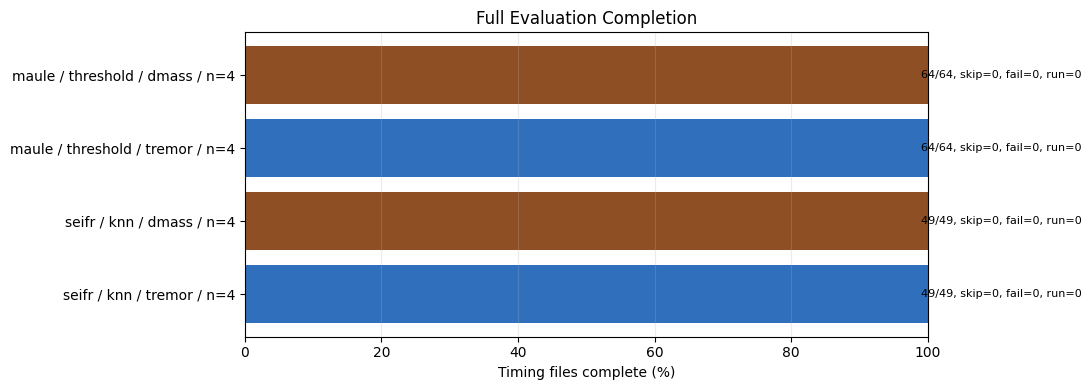

In [4]:
plot_completion(status);

## Runtime: Maule Threshold Search

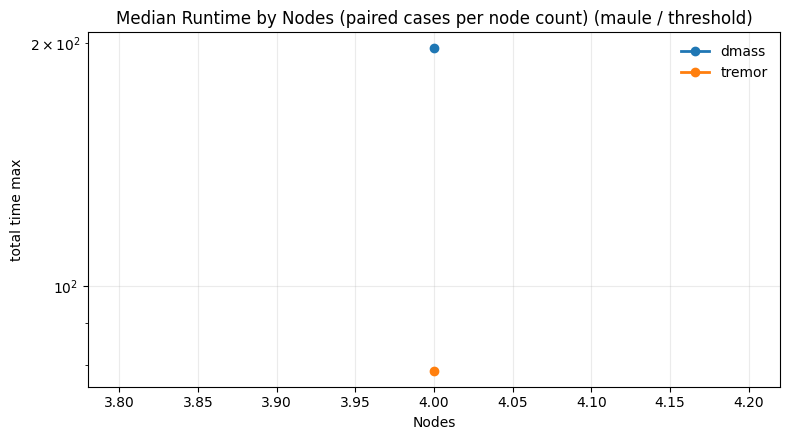

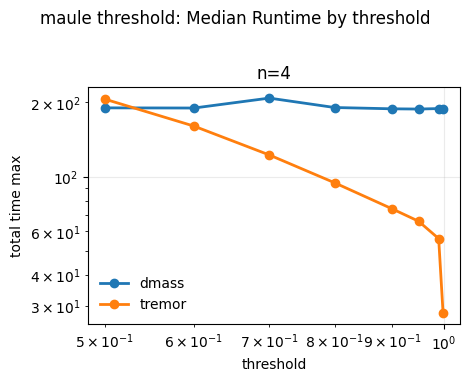

In [5]:
plot_median_runtime_by_nodes(timings, dataset="maule", workload="threshold", metric="total_time_max", log_y=True);
plot_runtime_by_parameter(timings, dataset="maule", workload="threshold", metric="total_time_max", log_y=True);

## Runtime: SeiFR k-NN Search

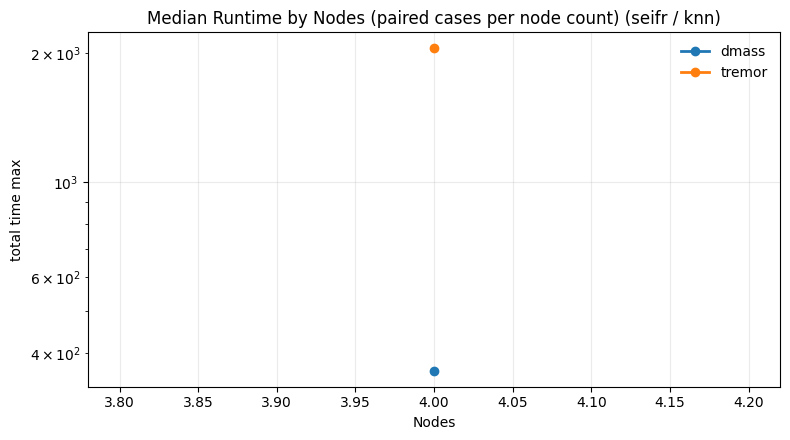

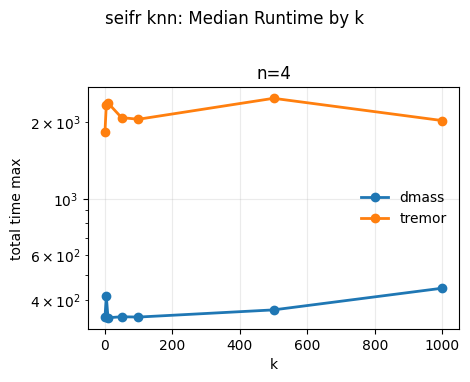

In [6]:
plot_median_runtime_by_nodes(timings, dataset="seifr", workload="knn", metric="total_time_max", log_y=True);
plot_runtime_by_parameter(timings, dataset="seifr", workload="knn", metric="total_time_max", log_y=True);

## Paired Speedups

`speedup_total_dmass_over_tremor > 1` means DMASS took longer than TREMOR for the same case/parameter/node count.

Paired completed comparisons: 113


,dataset,workload,case_id,nodes,replication_groups,window_length,query_count,waveform_samples,merge_offset,param_name,param_value,dmass_index_time_max,tremor_index_time_max,dmass_query_time_max,tremor_query_time_max,dmass_total_time_max,tremor_total_time_max,speedup_total_dmass_over_tremor,speedup_query_dmass_over_tremor,speedup_index_dmass_over_tremor
0,maule,threshold,XS_QC12_00_HHZ,4,0,496,50,967470654,124,threshold,0.5,10.566315,22.491590,250.045038,220.645666,260.611353,243.137256,1.071869,1.133242,0.469790
1,maule,threshold,XS_QF05_00_HHE,4,0,496,50,410750008,124,threshold,0.5,5.103531,15.086095,64.485416,94.290441,69.588947,109.376536,0.636233,0.683902,0.338294
2,maule,threshold,ZE_G04S__HHZ,4,0,992,50,2566388916,248,threshold,0.5,25.434121,64.329955,334.586465,664.453928,360.020586,728.783883,0.494002,0.503551,0.395370
3,maule,threshold,ZE_G14S__HHE,4,0,992,50,1267349410,248,threshold,0.5,14.487875,32.930270,247.452095,391.731545,261.939970,424.661815,0.616820,0.631688,0.439956
4,maule,threshold,ZE_GA1S__HHE,4,0,1000,50,87316288,250,threshold,0.5,2.457553,2.390451,21.020751,15.624207,23.478304,18.014658,1.303289,1.345396,1.028071
5,maule,threshold,ZE_GB2S__HHE,4,0,1000,22,8640001,250,threshold,0.5,1.034704,0.674787,1.172997,0.904837,2.207701,1.579624,1.397612,1.296363,1.533379
6,maule,threshold,ZE_GC2S__HHN,4,0,992,50,613697643,248,threshold,0.5,8.800231,19.103394,204.188355,209.649659,212.988586,228.753053,0.931085,0.973950,0.460663
7,maule,threshold,ZE_U65S__HHE,4,0,992,50,743243482,248,threshold,0.5,8.646640,20.820009,158.510191,162.809167,167.156831,183.629176,0.910296,0.973595,0.415304
8,maule,threshold,XS_QC12_00_HHZ,4,0,496,50,967470654,124,threshold,0.6,10.497765,22.046862,243.660922,182.991033,254.158687,205.037895,1.239569,1.331546,0.476157
9,maule,threshold,XS_QF05_00_HHE,4,0,496,50,410750008,124,threshold,0.6,5.997267,15.237534,64.690620,76.983560,70.687887,92.221094,0.766505,0.840317,0.393585


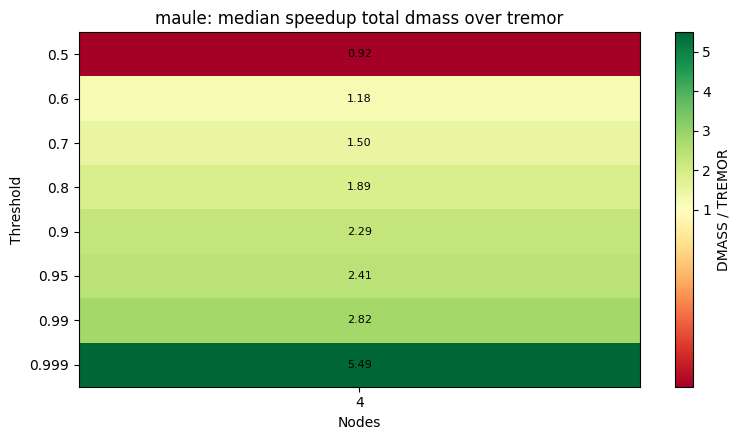

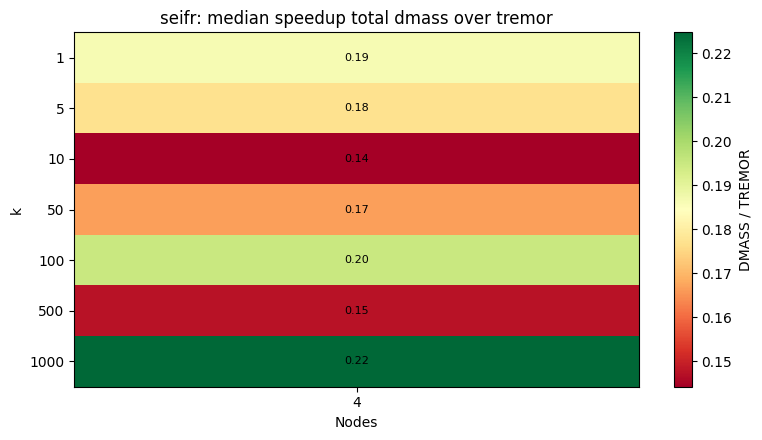

In [7]:
paired = paired_speedups(timings)
print(f"Paired completed comparisons: {len(paired):,}")
display(paired.head(20))

plot_speedup_heatmap(paired, dataset="maule", workload="threshold", value_col="speedup_total_dmass_over_tremor");
plot_speedup_heatmap(paired, dataset="seifr", workload="knn", value_col="speedup_total_dmass_over_tremor");

## Result Volume

Completed output prefixes: 226


,output_prefix,dataset,workload,algorithm,nodes,replication_groups,case_id,query_count,window_length,merge_offset,threshold,k,output_kind,output_file_count,output_bytes,sample_output_file,output_mb
56,../experiments/e...,maule,threshold,dmass,4,0,ZE_G04S__HHZ,50,992,248,0.5,NaN,threshold_shards,4,30805234,../experiments/e...,29.378160
120,../experiments/e...,maule,threshold,tremor,4,0,ZE_G04S__HHZ,50,992,248,0.5,NaN,threshold_shards,4,30805234,../experiments/e...,29.378160
121,../experiments/e...,maule,threshold,tremor,4,0,ZE_G04S__HHZ,50,992,248,0.6,NaN,threshold_shards,4,5911808,../experiments/e...,5.637939
57,../experiments/e...,maule,threshold,dmass,4,0,ZE_G04S__HHZ,50,992,248,0.6,NaN,threshold_shards,4,5911808,../experiments/e...,5.637939
24,../experiments/e...,maule,threshold,dmass,4,0,ZE_GC2S__HHN,50,992,248,0.5,NaN,threshold_shards,4,3750296,../experiments/e...,3.576561
88,../experiments/e...,maule,threshold,tremor,4,0,ZE_GC2S__HHN,50,992,248,0.5,NaN,threshold_shards,4,3750296,../experiments/e...,3.576561
80,../experiments/e...,maule,threshold,tremor,4,0,XS_QF05_00_HHE,50,496,124,0.5,NaN,threshold_shards,4,3078453,../experiments/e...,2.935842
16,../experiments/e...,maule,threshold,dmass,4,0,XS_QF05_00_HHE,50,496,124,0.5,NaN,threshold_shards,4,3078453,../experiments/e...,2.935842
162,../experiments/e...,seifr,knn,dmass,4,0,RD_MTLF__BHZ,50,3000,750,NaN,1000.0,single_csv,1,1449362,../experiments/e...,1.382219
211,../experiments/e...,seifr,knn,tremor,4,0,RD_MTLF__BHZ,50,3000,750,NaN,1000.0,single_csv,1,1449362,../experiments/e...,1.382219


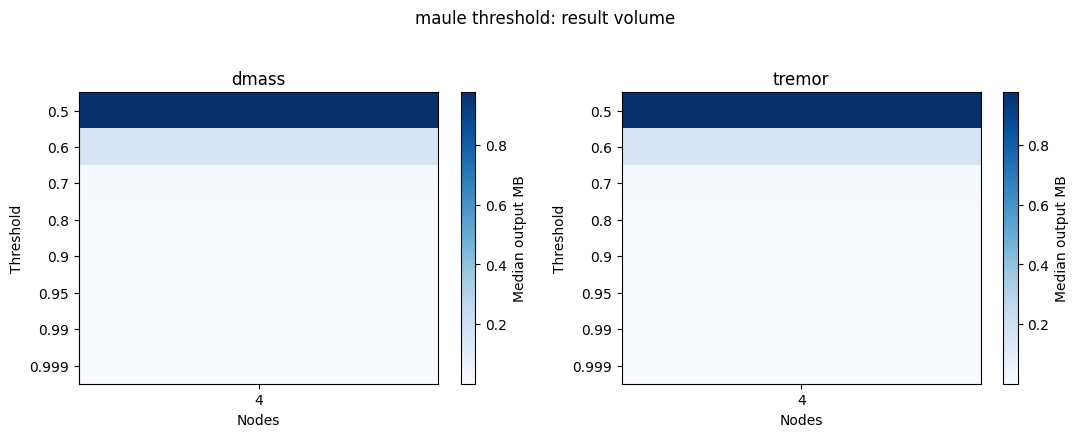

In [8]:
outputs = output_inventory(EVAL_ROOT, manifest)
print(f"Completed output prefixes: {len(outputs):,}")
display(outputs.sort_values("output_bytes", ascending=False).head(20))

plot_output_volume_heatmap(outputs, dataset="maule", workload="threshold");

## Persist Derived Tables

In [9]:
analysis_dir = save_analysis_tables(EVAL_ROOT, timings, status, paired, outputs, skips)
print(f"Wrote derived tables to {analysis_dir}")

Wrote derived tables to ../experiments/evals/final_sweep_n4_20260925/analysis


# Plots: TREMOR and the baselines

Query answering time only; index construction (TREMOR) and preprocessing (the baselines) are one-off costs per channel.
*Total* times sum all channels of a dataset; a method that has not completed every channel of a configuration gets no bar there, and the
graph says in red which results are pending. Methods: SSS (skip-sequential scan), DMASS-V1 (distributed MASS, one FFT over each node's whole
waveform part, `dmass/DMASS_V1.c`), DMASS-V3 (the piecewise FFTs of MASS V3, `dmass/DMASS_V3.c`), and TREMOR (index with
scan and FFT fallbacks). The evaluation (`experiments/submit_subsets.sh`) uses subsets: 20 Maule channels (56 GB) and the
7 SeiFR channels (42 GB), 50 templates per channel; threshold and k-NN search on both datasets, on 4 nodes with full
replication (`main`), for t = 0.8 and k = 5 on 1, 2, 8 nodes (`scale`), and with the replication strategies on 4 and 8
nodes (`repl4`, `repl8`). Replication strategy: `none` (each node holds a distinct part of the waveform), `partial-X`
(each part on X nodes), `full` (every node holds the whole waveform). Every figure is saved at its printed size (a
quarter of the page width) in `notebooks/figures/`, without a legend; the legends are separate strips (`legend_*.pdf`).

In [10]:
import csv
import textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

EVALS = Path('../experiments/evals')
PLOTS = Path('figures')  # the paper's figures
PLOTS.mkdir(parents=True, exist_ok=True)

# SSS: skip-sequential scan; DMASS-V1/V3: distributed MASS with one FFT over the whole series (V1) or piecewise FFTs
# (V3); TREMOR: index with scan and FFT fallbacks.
METHODS = ['SSS', 'DMASS-V1', 'DMASS-V3', 'TREMOR']
PENDING = []  # methods to keep in the close-match plot while they have no results
PLACEHOLDERS = []  # figures with pending results
LIGHT_ORANGE = '#fdae6b'
COLORS = {'SSS': '#3182bd', 'DMASS-V1': '#bdbdbd', 'DMASS-V3': '#737373', 'TREMOR': '#e6550d', 'index only': LIGHT_ORANGE,
          'SS': '#9ecae1'}
STRATEGIES = ['none', 'partial-2', 'partial-4', 'full']

# Every figure at its printed size, a quarter of the page width (7 in), with small fonts, a grid, no frame and no
# legend (10-01: taller, 1.7 x 1.0 in, and larger labels).
plt.rcParams.update({'figure.figsize': (1.7, 1.0), 'figure.constrained_layout.use': True,
                     'figure.constrained_layout.h_pad': 0.01, 'figure.constrained_layout.w_pad': 0.01,
                     'font.size': 8, 'axes.labelsize': 8, 'xtick.labelsize': 7, 'ytick.labelsize': 7, 'legend.fontsize': 7,
                     'legend.handlelength': 1.0, 'legend.handletextpad': 0.4, 'legend.columnspacing': 1.0,
                     'axes.grid': True, 'axes.grid.axis': 'y', 'grid.alpha': 0.5, 'grid.linewidth': 0.4,
                     'axes.axisbelow': True, 'axes.spines.left': False, 'axes.spines.right': False,
                     'axes.spines.top': False, 'axes.spines.bottom': False, 'xtick.major.size': 0,
                     'ytick.major.size': 0, 'ytick.minor.size': 0, 'xtick.minor.size': 0,
                     'xtick.major.pad': 1.5, 'ytick.major.pad': 1.5, 'axes.labelpad': 1.5, 'hatch.linewidth': 0.5,
                     'lines.linewidth': 1.0, 'pdf.fonttype': 42})

# Scope of the paper: selective queries.
THRESHOLDS = [0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 0.999]
THRESHOLD_COLORS = {t: plt.cm.Oranges(0.3 + 0.7 * i / (len(THRESHOLDS) - 1)) for i, t in enumerate(THRESHOLDS)}
KS = [1, 2, 5, 10]

# Evaluation roots and the TREMOR variant (or SSS) of their TREMOR runs, and the roots whose D-MASS runs are used.
N = (1, 2, 4, 8)
FULL = '20260928'  # earlier full-replication runs (script not in this repository)
ROOTS = {**{f'{kind}_{method}_{tag}': name for tag in [FULL + 'c', FULL + 'b', FULL] for kind in ['full', 'scale', 'repl8']
            for method, name in [('adaptive', 'TREMOR'), ('simple', 'index only'), ('sss', 'SSS')]},
         'seifrk_adaptive_20260929': 'TREMOR', 'seifrk_sss_20260929': 'SSS',  # SeiFR k = 2-20
         **{f'ss_{kind}_20260929': 'SS' for kind in ['full', 'scale', 'repl8']},  # earlier SS runs (script not in this repository)
         # earlier runs (used where the roots above have no run of the same configuration)
'final3_simple_sweep_n4_20260927': 'index only',       # Maule thresholds
         'final7_adaptive_maule_n4_20260927': 'TREMOR',
         'final7_simple_seifr_n4_20260927': 'index only',       # SeiFR k
         'final7_adaptive_seifr_n4_20260927': 'TREMOR',
         'mauleknn7_simple_n4_20260927': 'index only',          # Maule k (templates with close matches)
         'mauleknn7_adaptive_n4_20260927': 'TREMOR',
         'sss_sweep_n4_20260927': 'SSS', 'sss5_seifr_n4_20260927': 'SSS', 'mauleknn_sss_n4_20260927': 'SSS',
         'sss_scaling_20260927': 'SSS', 'sss5_scaling_seifr_20260927': 'SSS', 'sss_repl_n8_20260928': 'SSS',
         **{f'repl3_simple_n{n}_20260927': 'index only' for n in N},             # Maule th 0.8
         **{f'repl7_adaptive_maule_n{n}_20260927': 'TREMOR' for n in N},
         **{f'repl7_simple_seifr_n{n}_20260927': 'index only' for n in N},       # SeiFR k 10
         **{f'repl7_adaptive_seifr_n{n}_20260927': 'TREMOR' for n in N}}
DMASS_ROOTS = {**{root: 'DMASS-V1' for root in [f'full_adaptive_{FULL}', 'final_sweep_n4_20260925',
                                               'mauleknn_adaptive_n4_20260927', *[f'repl_n{n}_20260926' for n in N]]},
               **{f'dmassv3_{kind}_20260929': 'DMASS-V3' for kind in ['full', 'scale', 'repl8', 'mauleknn']},
               'seifrk_adaptive_20260929': 'DMASS-V1', 'seifrk_dmassv3_20260929': 'DMASS-V3'}


def strategy(nodes, groups):
    copies = nodes // (groups or nodes)  # replication groups = 0 means one group per node
    return 'full' if copies == nodes else 'none' if copies == 1 else f'partial-{copies}'  # 1 node: full


def load_runs(roots, dmass_roots={}):
    """One row per completed run: the TREMOR runs of {root: method} and the D-MASS runs of {root: method}."""
    rows = []
    for root, algorithm, method in [(r, 'tremor', m) for r, m in roots.items()] + [(r, 'dmass', m) for r, m in dmass_roots.items()]:
        for plan in (EVALS / root / 'plans').glob(f'*.{algorithm}.*.tsv'):
            for run in csv.DictReader(open(plan), delimiter='\t'):
                timings = Path(run['output_prefix'] + '.timings.csv')
                if not timings.exists():
                    continue
                t = pd.read_csv(timings)  # one row per node
                nodes, groups = int(run['nodes']), int(run['replication_groups'])
                rows.append({'root': root, 'method': method, 'run': run['run_id'], 'output': run['output_prefix'],
                             'dataset': run['dataset'], 'channel': run['case_id'], 'samples': int(run['waveform_samples']),
                             'window': int(run['window_length']),
                             'queries': int(run['query_count']), 'nodes': nodes, 'strategy': strategy(nodes, groups),
                             'threshold': float(run['threshold']) if run['threshold'] != 'NA' else np.nan,
                             'k': float(run['k']) if run['k'] != 'NA' else np.nan,
                             'raw_gb': 4e-9 * int(run['waveform_samples']) / (groups or nodes),
                             'index_time': t.index_time.max(), 'query_time': t.query_time.max(),
                             'index_gb': t.index_gb.max() if 'index_gb' in t else np.nan})  # largest node
    return pd.DataFrame(rows, columns=['root', 'method', 'run', 'output', 'dataset', 'channel', 'samples', 'window', 'queries', 'nodes',
                                       'strategy', 'threshold', 'k', 'raw_gb', 'index_time', 'query_time', 'index_gb'])


# The evaluation (experiments/submit_subsets.sh), and the earlier runs (indexing table, ablation).
TAG = '20260929'
KINDS = ['main', 'scale', 'repl4', 'repl8', 'scalet09', 'repl4t09', 'main8', 'repl8t09', 'repl8k5']  # scale, repl4, repl8: t = 0.8 and k = 5; ...t09: t = 0.9; main8: the rest of the t / k sweep on 8 nodes
T_DEFAULT = 0.9  # the threshold of the experiments that vary the nodes and the replication degree (k = 5)
EVAL_ROOTS = {f'sub_{method}_{kind}_{TAG}': name for kind in KINDS
              for method, name in [('tremor', 'TREMOR'), ('sss', 'SSS')]}
EVAL_DMASS = {f'sub_{method}_{kind}_{TAG}': name for kind in KINDS
              for method, name in [('dmassv1', 'DMASS-V1'), ('dmassv3', 'DMASS-V3')]}
runs = load_runs(EVAL_ROOTS, EVAL_DMASS)
runs = runs[runs.threshold.isin(THRESHOLDS) | runs.k.isin(KS)]
old_runs = load_runs(ROOTS, DMASS_ROOTS)
old_runs = old_runs.drop_duplicates(['method', 'dataset', 'channel', 'nodes', 'strategy', 'threshold', 'k'])  # first root wins
runs.assign(workload=np.where(runs.k.notna(), 'knn', 'threshold')).groupby(
    ['dataset', 'workload', 'method', 'nodes', 'strategy']).size().unstack('method')

method                             DMASS-V1  DMASS-V3    SSS  TREMOR
dataset workload  nodes strategy                                    
maule   knn       1     full           20.0      20.0   20.0    20.0
                  2     full           20.0      20.0   20.0    20.0
                  4     full           80.0      80.0   80.0    80.0
                        none           20.0      20.0   20.0    20.0
                        partial-2      20.0      20.0   20.0    20.0
                  8     full           20.0      20.0   20.0    20.0
                        none            NaN      20.0   20.0    20.0
                        partial-2       NaN      20.0   20.0    20.0
                        partial-4       NaN      20.0   20.0    20.0
        threshold 1     full           40.0      40.0   40.0    40.0
                  2     full           40.0      40.0   40.0    40.0
                  4     full          140.0     140.0  140.0   140.0
                        none           20.0      20.0   23.0    40.0
                        partial-2      20.0      20.0   23.0    40.0
                  8     full           40.0      40.0   40.0    40.0
                        none            NaN      20.0   20.0    20.0
                        partial-2       NaN      20.0   20.0    20.0
                        partial-4       NaN      20.0   20.0    20.0
seifr   knn       1     full            7.0       7.0    7.0     7.0
                  2     full            7.0       7.0    7.0     7.0
                  4     full           28.0      28.0   28.0    28.0
                        none            7.0       7.0    7.0     7.0
                        partial-2       7.0       7.0    7.0     7.0
                  8     full            7.0       7.0    7.0     7.0
                        none            NaN       7.0    7.0     7.0
                        partial-2       NaN       7.0    7.0     7.0
                        partial-4       NaN       7.0    7.0     7.0
        threshold 1     full           14.0      14.0   14.0    14.0
                  2     full           14.0      14.0   14.0    14.0
                  4     full           49.0      49.0   49.0    49.0
                        none            7.0       7.0    7.0    14.0
                        partial-2       7.0       7.0    7.0    14.0
                  8     full           14.0      14.0   14.0    14.0
                        none            NaN       7.0    7.0     7.0
                        partial-2       NaN       7.0    7.0     7.0
                        partial-4       NaN       7.0    7.0     7.0

In [11]:
def total(d, x, value, methods, expected=None):
    """Sum of `value` over all channels of the dataset, per x and method. A method that has not completed every channel
    at an x gets no value there (no bar; the graph names the pending results). `expected`: the x values to show.
    table.attrs['channels']: channels completed per x and method."""
    channels = runs[runs.dataset.isin(d.dataset.unique())].channel.unique()
    if d.empty:
        table = pd.DataFrame(index=expected or [], columns=methods, dtype=float)
        table.attrs['channels'] = table.fillna(0)
        return table
    per_channel = d.pivot_table(index='channel', columns=[x, 'method'], values=value).reindex(channels)
    table = per_channel.sum(skipna=False).unstack('method')
    done = per_channel.notna().sum().unstack('method')
    xs = expected or list(table.index)
    table = table.reindex(index=xs, columns=methods)
    table.index.name = x
    table.attrs['channels'] = done.reindex(index=xs, columns=methods).fillna(0).astype(int)
    return table


def log_ticks(ax):
    """Plain-number ticks on a log y axis, in 1-2-5 steps when it spans little more than a decade (short figures)."""
    low, high = ax.get_ylim()
    ax.yaxis.set_major_locator(mticker.LogLocator(subs=(1.0,) if high / low > 30 else (1.0, 2.0, 5.0)))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:g}'))
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())


def short(value):
    """Tick label: 0.95 -> .95, 10.0 -> 10."""
    return f'{value:g}'.lstrip('0') if isinstance(value, float) and value < 1 else f'{value:g}' if isinstance(value, float) else value


def pending_figure(name, message=''):
    """A message instead of a graph that is not ready, so that the paper compiles."""
    fig, ax = plt.subplots()
    ax.axis('off')
    lines = ('results pending' + message.replace('pending', '', 1)).split('\n')
    text = '\n'.join(part for line in lines for part in textwrap.wrap(line, 40))
    ax.text(0.5, 0.5, text, ha='center', va='center', color='red', fontsize=6)
    fig.savefig(PLOTS / f'{name}.pdf')
    plt.close(fig)
    print(f'{name}: not ready')


def pending_message(missing):
    """'pending: ...' for a table of missing results (x by method); empty when nothing is missing."""
    per_method = {m: ', '.join(str(x) for x in missing.index[missing[m]]) for m in missing.columns if missing[m].any()}
    if not per_method:
        return ''
    if len(set(per_method.values())) == 1:  # the same x values for every method
        return f"pending at {next(iter(per_method.values()))}:\n{', '.join(per_method)}"
    return 'pending:\n' + '; '.join(f'{m} ({xs})' for m, xs in per_method.items())


def bar_plot(table, xlabel, ylabel, name, colors, logy=False, xticklabels=None, tick_rotation=0):
    """One bar per column of `table` for every x; saved as PLOTS/<name>.pdf (the legend is a separate strip). Results
    that are not in yet get no bar, and the graph says in red which ones are pending; while some x has results for
    less than half of the columns, the graph is not ready and only the message is shown."""
    table = table.copy()
    table.index = [short(v) for v in table.index]
    message = pending_message(table.isna())
    if message:
        PLACEHOLDERS.append(name)
    if (table.notna().sum(axis=1) < len(table.columns) / 2).any():
        return pending_figure(name, message)
    fig, ax = plt.subplots()
    table.plot.bar(ax=ax, rot=0, logy=logy, color=colors, legend=False, width=0.85)
    ax.grid(False, axis='x')  # pandas turns on both grids
    if logy:
        log_ticks(ax)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if xticklabels is not None:  # text of the x ticks, smaller
        ax.set_xticklabels(xticklabels, fontsize=6, rotation=tick_rotation, ha='right' if tick_rotation else 'center',
                           rotation_mode='anchor')
    if len(table) > 5:  # many groups: smaller tick labels
        ax.tick_params(axis='x', labelsize=6)
    if message:
        ax.set_title(message.replace('\n', ' '), fontsize=5, color='red', pad=1)
    fig.savefig(PLOTS / f'{name}.pdf')
    plt.show()


def legend_strip(labels, colors, name, ncol=None):
    """A legend on its own (one row, or ncol columns), for the top of a figure row; saved as PLOTS/legend_<name>.pdf."""
    labels, handles = list(labels), [plt.Rectangle((0, 0), 1, 1, color=color) for color in colors]
    fig = plt.figure(figsize=(7, 0.2))
    fig.legend(handles, labels, loc='center', ncol=ncol or len(labels), frameon=False)
    fig.savefig(PLOTS / f'legend_{name}.pdf', bbox_inches='tight', pad_inches=0.01)
    plt.close(fig)


legend_strip(METHODS, [COLORS[m] for m in METHODS], 'methods')
legend_strip(METHODS, [COLORS[m] for m in METHODS], 'methods_2rows', ncol=2)
legend_strip([f't = {t:g}' for t in THRESHOLDS], THRESHOLD_COLORS.values(), 'thresholds', ncol=4)


def suffix(methods):
    """File name suffix: empty for all methods, otherwise the shown methods."""
    return '' if list(methods) == METHODS else '_' + '_'.join(methods)


def label(param, value):
    return f'th{value}' if param == 'threshold' else f'k{value:g}'


def print_speedups(table):
    """Total query time (s) per method, the channels each method completed, and TREMOR's speedup over every baseline."""
    parts = [table.round(1), table.attrs['channels'].add_prefix('channels, ')]
    parts += [(table[m] / table['TREMOR']).round(2).rename(f'TREMOR vs {m}') for m in table.columns if m != 'TREMOR']
    print(pd.concat(parts, axis=1).to_string(), '\n')

## Query answering time vs. number of nodes
Full replication; t = 0.9 (`T_DEFAULT`) and k = 5 on both datasets.


query_time_vs_nodes_maule_th0.9_repl-full
         SSS  DMASS-V1  DMASS-V3  TREMOR  channels, SSS  channels, DMASS-V1  channels, DMASS-V3  channels, TREMOR  TREMOR vs SSS  TREMOR vs DMASS-V1  TREMOR vs DMASS-V3
nodes                                                                                                                                                                   
1      318.5   13439.2    1402.5   103.6             20                  20                  20                20           3.08              129.75               13.54
2      164.6    6789.4     727.7    62.6             20                  20                  20                20           2.63              108.40               11.62
4       81.9    3364.3     415.8    29.5             20                  20                  20                20           2.78              114.16               14.11
8       46.9    1873.6     227.9    19.8             20                  20                  20                20

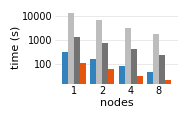

query_time_vs_nodes_maule_k5_repl-full
         SSS  DMASS-V1  DMASS-V3  TREMOR  channels, SSS  channels, DMASS-V1  channels, DMASS-V3  channels, TREMOR  TREMOR vs SSS  TREMOR vs DMASS-V1  TREMOR vs DMASS-V3
nodes                                                                                                                                                                   
1      480.0   11841.7    1055.9   176.0             20                  20                  20                20           2.73               67.26                6.00
2      247.0    5985.5     559.3    89.4             20                  20                  20                20           2.76               66.98                6.26
4      131.7    3356.7     317.1    47.9             20                  20                  20                20           2.75               70.12                6.63
8       69.0    2101.7     179.2    25.5             20                  20                  20                20   

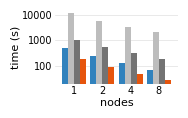

query_time_vs_nodes_seifr_th0.9_repl-full
         SSS  DMASS-V1  DMASS-V3  TREMOR  channels, SSS  channels, DMASS-V1  channels, DMASS-V3  channels, TREMOR  TREMOR vs SSS  TREMOR vs DMASS-V1  TREMOR vs DMASS-V3
nodes                                                                                                                                                                   
1      442.2    8143.0    1185.5   112.1              7                   7                   7                 7           3.94               72.61               10.57
2      218.3    4115.6     577.8    59.9              7                   7                   7                 7           3.65               68.76                9.65
4      110.2    2220.5     303.7    30.3              7                   7                   7                 7           3.64               73.26               10.02
8       60.1    1264.0     169.9    17.3              7                   7                   7                 7

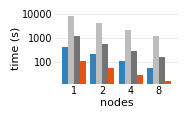

query_time_vs_nodes_seifr_k5_repl-full
          SSS  DMASS-V1  DMASS-V3  TREMOR  channels, SSS  channels, DMASS-V1  channels, DMASS-V3  channels, TREMOR  TREMOR vs SSS  TREMOR vs DMASS-V1  TREMOR vs DMASS-V3
nodes                                                                                                                                                                    
1      1655.3    7617.6     774.6   138.5              7                   7                   7                 7          11.95               54.99                5.59
2       840.8    3970.0     420.1    73.0              7                   7                   7                 7          11.52               54.40                5.76
4       429.3    2160.1     219.5    38.1              7                   7                   7                 7          11.25               56.64                5.75
8       227.6    1280.3     142.4    20.5              7                   7                   7               

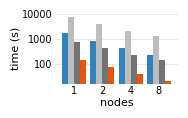

In [12]:
def plot_query_time_vs_nodes(dataset, param, value, strategy='full', methods=METHODS):
    d = runs[(runs.dataset == dataset) & (runs[param] == value) & (runs.strategy == strategy)]
    table = total(d, 'nodes', 'query_time', methods, expected=[1, 2, 4, 8])
    name = f'query_time_vs_nodes_{dataset}_{label(param, value)}_repl-{strategy}' + suffix(methods)
    print(name)
    print_speedups(table)
    bar_plot(table, 'nodes', 'time (s)', name, [COLORS[m] for m in table.columns], logy=True)


for dataset in ['maule', 'seifr']:
    plot_query_time_vs_nodes(dataset, 'threshold', T_DEFAULT)
    plot_query_time_vs_nodes(dataset, 'k', 5)

## Query answering time vs. threshold and k (4 nodes, full replication)

query_time_vs_threshold_maule_4nodes_repl-full
             SSS  DMASS-V1  DMASS-V3  TREMOR  channels, SSS  channels, DMASS-V1  channels, DMASS-V3  channels, TREMOR  TREMOR vs SSS  TREMOR vs DMASS-V1  TREMOR vs DMASS-V3
threshold                                                                                                                                                                   
0.600      121.8    3439.1     417.8    45.2             20                  20                  20                20           2.69               76.02                9.24
0.700      107.0    3409.5     426.2    42.8             20                  20                  20                20           2.50               79.69                9.96
0.800       91.1    3398.3     433.6    39.1             20                  20                  20                20           2.33               86.95               11.09
0.900       81.9    3364.3     415.8    29.5             20                  20         

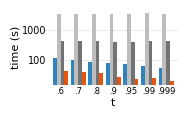

query_time_vs_k_maule_4nodes_repl-full
      SSS  DMASS-V1  DMASS-V3  TREMOR  channels, SSS  channels, DMASS-V1  channels, DMASS-V3  channels, TREMOR  TREMOR vs SSS  TREMOR vs DMASS-V1  TREMOR vs DMASS-V3
k                                                                                                                                                                    
1    84.8    3250.2     291.8    40.1             20                  20                  20                20           2.11               80.99                7.27
2   120.0    3237.7     316.5    46.1             20                  20                  20                20           2.61               70.27                6.87
5   131.7    3356.7     317.1    47.9             20                  20                  20                20           2.75               70.12                6.63
10  133.8    3275.4     322.2    45.2             20                  20                  20                20           2.96      

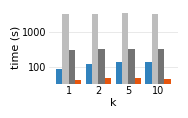

query_time_vs_threshold_seifr_4nodes_repl-full
             SSS  DMASS-V1  DMASS-V3  TREMOR  channels, SSS  channels, DMASS-V1  channels, DMASS-V3  channels, TREMOR  TREMOR vs SSS  TREMOR vs DMASS-V1  TREMOR vs DMASS-V3
threshold                                                                                                                                                                   
0.600      229.7    2213.3     301.8    35.3              7                   7                   7                 7           6.52               62.78                8.56
0.700      184.5    2232.6     303.8    35.6              7                   7                   7                 7           5.19               62.76                8.54
0.800      146.2    2200.8     304.1    33.3              7                   7                   7                 7           4.39               66.11                9.13
0.900      110.2    2220.5     303.7    30.3              7                   7         

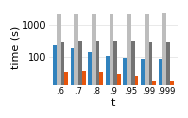

query_time_vs_k_seifr_4nodes_repl-full
      SSS  DMASS-V1  DMASS-V3  TREMOR  channels, SSS  channels, DMASS-V1  channels, DMASS-V3  channels, TREMOR  TREMOR vs SSS  TREMOR vs DMASS-V1  TREMOR vs DMASS-V3
k                                                                                                                                                                    
1   164.0    2098.4     237.9    31.8              7                   7                   7                 7           5.15               65.93                7.48
2   404.9    2112.1     224.9    36.6              7                   7                   7                 7          11.06               57.70                6.14
5   429.3    2160.1     219.5    38.1              7                   7                   7                 7          11.25               56.64                5.75
10  440.6    2120.3     228.7    37.2              7                   7                   7                 7          11.86      

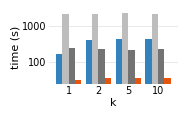

query_time_vs_threshold_maule_8nodes_repl-full
            SSS  DMASS-V1  DMASS-V3  TREMOR  channels, SSS  channels, DMASS-V1  channels, DMASS-V3  channels, TREMOR  TREMOR vs SSS  TREMOR vs DMASS-V1  TREMOR vs DMASS-V3
threshold                                                                                                                                                                  
0.600       NaN       NaN       NaN     NaN              0                   0                   0                 0            NaN                 NaN                 NaN
0.700       NaN       NaN       NaN     NaN              0                   0                   0                 0            NaN                 NaN                 NaN
0.800      50.0    2151.0     254.5    24.5             20                  20                  20                20           2.04               87.77               10.38
0.900      46.9    1873.6     227.9    19.8             20                  20               

In [13]:
def plot_query_time_vs_param(dataset, param, nodes=4, strategy='full', methods=METHODS):
    d = runs[(runs.dataset == dataset) & (runs.nodes == nodes) & (runs.strategy == strategy) & runs[param].notna()]
    table = total(d, param, 'query_time', methods, expected=THRESHOLDS if param == 'threshold' else KS)
    name = f'query_time_vs_{param}_{dataset}_{nodes}nodes_repl-{strategy}' + suffix(methods)
    print(name)
    print_speedups(table)
    bar_plot(table, 't' if param == 'threshold' else 'k', 'time (s)', name, [COLORS[m] for m in table.columns], logy=True)


for nodes in [4, 8]:
    for dataset in ['maule', 'seifr']:
        plot_query_time_vs_param(dataset, 'threshold', nodes)
        plot_query_time_vs_param(dataset, 'k', nodes)

## Query answering time vs. replication degree (fixed number of nodes)
Replication degree: the number of nodes that hold each part of the waveform (1: no replication; all nodes: full
replication). 4 nodes are the default of the paper; the 8-node version is also saved.

query_time_vs_replication_maule_th0.9_4nodes
            SSS  DMASS-V1  DMASS-V3  TREMOR  channels, SSS  channels, DMASS-V1  channels, DMASS-V3  channels, TREMOR  TREMOR vs SSS  TREMOR vs DMASS-V1  TREMOR vs DMASS-V3
strategy                                                                                                                                                                   
none       88.3    3592.9     476.0    49.8             20                  20                  20                20           1.77               72.09                9.55
partial-2  82.6    3386.8     456.5    39.5             20                  20                  20                20           2.09               85.75               11.56
full       81.9    3364.3     415.8    29.5             20                  20                  20                20           2.78              114.16               14.11 



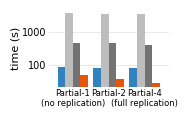

query_time_vs_replication_maule_k5_4nodes
             SSS  DMASS-V1  DMASS-V3  TREMOR  channels, SSS  channels, DMASS-V1  channels, DMASS-V3  channels, TREMOR  TREMOR vs SSS  TREMOR vs DMASS-V1  TREMOR vs DMASS-V3
strategy                                                                                                                                                                    
none       145.7    3547.1     352.9    52.6             20                  20                  20                20           2.77               67.49                6.71
partial-2  133.0    3390.9     336.7    50.0             20                  20                  20                20           2.66               67.76                6.73
full       131.7    3356.7     317.1    47.9             20                  20                  20                20           2.75               70.12                6.63 



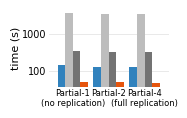

query_time_vs_replication_seifr_th0.9_4nodes
             SSS  DMASS-V1  DMASS-V3  TREMOR  channels, SSS  channels, DMASS-V1  channels, DMASS-V3  channels, TREMOR  TREMOR vs SSS  TREMOR vs DMASS-V1  TREMOR vs DMASS-V3
strategy                                                                                                                                                                    
none       112.4    2661.1     338.8    35.8              7                   7                   7                 7           3.14               74.23                9.45
partial-2  111.4    2448.1     341.7    34.8              7                   7                   7                 7           3.20               70.34                9.82
full       110.2    2220.5     303.7    30.3              7                   7                   7                 7           3.64               73.26               10.02 



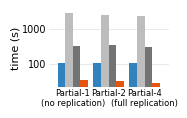

query_time_vs_replication_seifr_k5_4nodes
             SSS  DMASS-V1  DMASS-V3  TREMOR  channels, SSS  channels, DMASS-V1  channels, DMASS-V3  channels, TREMOR  TREMOR vs SSS  TREMOR vs DMASS-V1  TREMOR vs DMASS-V3
strategy                                                                                                                                                                    
none       457.2    2545.5     250.0    42.2              7                   7                   7                 7          10.82               60.25                5.92
partial-2  443.8    2346.5     242.3    42.1              7                   7                   7                 7          10.53               55.67                5.75
full       429.3    2160.1     219.5    38.1              7                   7                   7                 7          11.25               56.64                5.75 



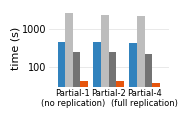

query_time_vs_replication_maule_th0.9_8nodes
            SSS  DMASS-V1  DMASS-V3  TREMOR  channels, SSS  channels, DMASS-V1  channels, DMASS-V3  channels, TREMOR  TREMOR vs SSS  TREMOR vs DMASS-V1  TREMOR vs DMASS-V3
strategy                                                                                                                                                                   
none        NaN       NaN       NaN     NaN              0                   0                   0                 0            NaN                 NaN                 NaN
partial-2   NaN       NaN       NaN     NaN              0                   0                   0                 0            NaN                 NaN                 NaN
partial-4   NaN       NaN       NaN     NaN              0                   0                   0                 0            NaN                 NaN                 NaN
full       46.9    1873.6     227.9    19.8             20                  20                 

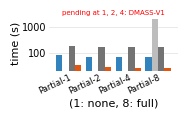

query_time_vs_replication_seifr_th0.9_8nodes
            SSS  DMASS-V1  DMASS-V3  TREMOR  channels, SSS  channels, DMASS-V1  channels, DMASS-V3  channels, TREMOR  TREMOR vs SSS  TREMOR vs DMASS-V1  TREMOR vs DMASS-V3
strategy                                                                                                                                                                   
none        NaN       NaN       NaN     NaN              0                   0                   0                 0            NaN                 NaN                 NaN
partial-2   NaN       NaN       NaN     NaN              0                   0                   0                 0            NaN                 NaN                 NaN
partial-4   NaN       NaN       NaN     NaN              0                   0                   0                 0            NaN                 NaN                 NaN
full       60.1    1264.0     169.9    17.3              7                   7                 

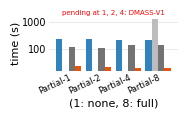

figures with pending results: ['query_time_vs_threshold_maule_8nodes_repl-full', 'query_time_vs_k_maule_8nodes_repl-full', 'query_time_vs_threshold_seifr_8nodes_repl-full', 'query_time_vs_k_seifr_8nodes_repl-full', 'query_time_vs_replication_maule_th0.9_8nodes', 'query_time_vs_replication_maule_k5_8nodes', 'query_time_vs_replication_seifr_th0.9_8nodes', 'query_time_vs_replication_seifr_k5_8nodes']


In [14]:
def plot_query_time_vs_replication(dataset, param, value, nodes=4, methods=METHODS):
    d = runs[(runs.dataset == dataset) & (runs[param] == value) & (runs.nodes == nodes)]
    degrees = {'none': 1, 'partial-2': 2, 'partial-4': 4, 'full': nodes}
    table = total(d, 'strategy', 'query_time', methods, expected=[s for s in STRATEGIES if degrees[s] <= nodes and s != f'partial-{nodes}'])
    name = f'query_time_vs_replication_{dataset}_{label(param, value)}_{nodes}nodes' + suffix(methods)
    print(name)
    print_speedups(table)
    table.index = [degrees[s] for s in table.index]
    # Partial-r: every part of the waveform is held by r nodes (Partial-1: no replication; Partial-<nodes>: full)
    if len(table) <= 3:  # 4 nodes: the extremes explained under their ticks
        ticks = [f'Partial-{r}' + ('\n(no replication)' if r == 1 else '\n(full replication)' if r == nodes else '') for r in table.index]
        bar_plot(table, '', 'time (s)', name, [COLORS[m] for m in table.columns], logy=True, xticklabels=ticks)
    else:  # more degrees: tilted ticks, the extremes explained in the axis title
        bar_plot(table, f'(1: none, {nodes}: full)', 'time (s)', name, [COLORS[m] for m in table.columns], logy=True,
                 xticklabels=[f'Partial-{r}' for r in table.index], tick_rotation=25)


for nodes in [4, 8]:
    for dataset in ['maule', 'seifr']:
        plot_query_time_vs_replication(dataset, 'threshold', T_DEFAULT, nodes)
        plot_query_time_vs_replication(dataset, 'k', 5, nodes)

print('figures with pending results:', PLACEHOLDERS)


## TREMOR indexing: time, ingestion rate, and index size per node (table)
Every TREMOR run builds its index; each value is the median of the builds of a configuration (the t = 0.8,
t = 0.9 and k = 5 runs). Index time = total over the channels (minutes); ingestion rate = subsequences indexed per second (all channels
together); index size = memory of the index on the most loaded node (mean over channels), next to the raw waveform data
held by a node. Only configurations whose channels all completed are shown.

In [15]:
def indexing(dataset):
    """TREMOR index construction per (nodes, strategy): time (minutes, all channels), ingestion rate (million
    subsequences indexed per second), index size per node (GB, mean over the channels)."""
    # Table 2 of the paper: the builds of the t = 0.8, t = 0.9, and k = 5 runs of the evaluation (not those of the 8-node
    # runs of 10-01: main8, repl8t09, repl8k5)
    d = runs[(runs.dataset == dataset) & (runs.method == 'TREMOR') & (runs.threshold.isin([0.8, 0.9]) | (runs.k == 5))
             & ~runs.root.str.contains('main8|repl8t09|repl8k5')]
    d = d.assign(subsequences=d.samples - d.window + 1)
    d = d.groupby(['nodes', 'strategy', 'channel'])[['index_time', 'subsequences', 'index_gb', 'raw_gb']].median()
    table = d.groupby(level=['nodes', 'strategy']).agg(channels=('subsequences', 'size'), index_time=('index_time', 'sum'),
                                                       subsequences=('subsequences', 'sum'), index_gb=('index_gb', 'mean'),
                                                       raw_gb=('raw_gb', 'mean'))
    table = table[table.channels == table.channels.max()]
    table['minutes'] = table.index_time / 60
    table['ingestion'] = table.subsequences / table.index_time / 1e6
    table['index / raw data'] = table.index_gb / table.raw_gb
    table['largest index (GB)'] = d.index_gb.groupby(level=['nodes', 'strategy']).max()
    order = [(n, s) for n in N for s in STRATEGIES if (n, s) in table.index]
    return table.loc[order, ['channels', 'minutes', 'ingestion', 'index_gb', 'raw_gb', 'index / raw data', 'largest index (GB)']]


for dataset in ['maule', 'seifr']:
    print(dataset)
    print(indexing(dataset).round(2).rename(columns={'minutes': 'index time (min)', 'ingestion': 'M subsequences/s',
                                                     'index_gb': 'index GB/node', 'raw_gb': 'raw GB/node'}).to_string(), '\n')

maule
                 channels  index time (min)  M subsequences/s  index GB/node  raw GB/node  index / raw data  largest index (GB)
nodes strategy                                                                                                                 
1     full             20             20.98             11.03          75.41         2.78             27.15              185.82
2     full             20             24.44              9.47          75.41         2.78             27.15              185.82
4     none             20             10.68             21.66          26.95         0.69             38.82               56.06
      partial-2        20             15.74             14.70          43.02         1.39             30.98               99.80
      full             20             25.31              9.15          75.41         2.78             27.15              185.82
8     none             20              7.84             29.53          18.80         0.35         

## TREMOR ingestion: time to add one more GB to the index (table)
TREMOR builds its index over growing prefixes (1 GB, 2 GB, ... of raw float32 data) of the largest channel of each
dataset of the evaluation (`experiments/ingestion.slurm`, no replication, median of 2 builds). The time to add one more
GB is the difference in index construction time between consecutive prefixes, divided by their size difference.

In [16]:
ING = EVALS / 'ingestion_20260930'  # current binary (with the FFT spectra); before: ingestion_20260927
if not list(ING.glob('ingestion.n*.csv')):
    ING = EVALS / 'ingestion_20260927'
print(ING.name)
ING = pd.concat(pd.read_csv(f) for f in ING.glob('ingestion.n*.csv'))
ing = ING.groupby(['dataset', 'nodes', 'gb'], as_index=False)[['index_time', 'index_gb']].median()
by_config = ing.groupby(['dataset', 'nodes'])
ing['seconds_per_gb'] = by_config.index_time.diff() / by_config.gb.diff()  # cost of the last added GB
ing['seconds_per_gb'] = ing.seconds_per_gb.fillna(ing.index_time / ing.gb)  # first prefix: from an empty index

for dataset in ['maule', 'seifr']:
    d = ing[ing.dataset == dataset]
    print(f'{dataset}: seconds to add one GB (by GB already indexed), and total index time')
    print(d.pivot(index='gb', columns='nodes', values='seconds_per_gb').round(1).to_string())
    print(d.pivot(index='gb', columns='nodes', values='index_time').round(1).to_string())
    first = d[d.gb == d.gb.min()].set_index('nodes').seconds_per_gb
    later = d[d.gb > d.gb.min()].groupby('nodes').seconds_per_gb
    print(pd.DataFrame({'first GB (s)': first, 'next GBs, mean (s)': later.mean(), 'min': later.min(),
                        'max': later.max()}).round(1).to_string(), '\n')

ingestion_20260930
maule: seconds to add one GB (by GB already indexed), and total index time
nodes       1     2     4     8
gb                             
1.00000  27.2  26.7  24.1  19.3
2.00000  17.4  10.3   7.1   4.0
3.00000  18.7  11.5   4.6   3.3
4.00000  19.4  12.9   6.6   4.4
5.00000  20.5  11.8   6.8   2.9
6.00000  19.5  13.3   7.5   2.3
7.00000  17.3  13.2   5.5   2.0
7.29502  19.4   9.1   5.9   4.9
nodes        1      2     4     8
gb                               
1.00000   27.2   26.7  24.1  19.3
2.00000   44.6   36.9  31.3  23.2
3.00000   63.3   48.4  35.8  26.5
4.00000   82.7   61.3  42.4  30.9
5.00000  103.2   73.1  49.3  33.8
6.00000  122.7   86.4  56.8  36.0
7.00000  140.0   99.6  62.3  38.0
7.29502  145.8  102.3  64.0  39.4
       first GB (s)  next GBs, mean (s)   min   max
nodes                                              
1              27.2                18.9  17.3  20.5
2              26.7                11.7   9.1  13.3
4              24.1                 6.

## TREMOR: index, scan, or FFT?
For every template and node, TREMOR computes the lower bound of a sample of $2^{16}$ subsequences and logs the
fraction within the search bound (the threshold distance, or for $k$-NN the first bound found in the index). It searches
the index if the fraction is at most $f = 1\%$, runs a skip-sequential scan if it is below $b = 5\%$, and otherwise scans
without lower bounds (4 nodes, full replication).

maule, threshold: % of templates per strategy, and sampled fraction (median, min)
       index  skip-seq. scan  scan w/o LBs   FFT  median     min
param                                                           
0.600    0.0             0.0          12.0  88.0  1.0000  1.0000
0.700    0.0             0.0          27.6  72.4  1.0000  1.0000
0.800    0.0             0.0          56.4  43.6  1.0000  0.9997
0.900    0.0             0.0          96.1   3.9  1.0000  0.8503
0.950    0.0             0.0          94.0   6.0  0.9983  0.1731
0.990    9.1             5.6          81.5   3.9  0.5019  0.0000
0.999   86.0             5.9           4.7   3.4  0.0001  0.0000 



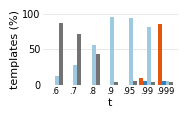

maule, k: % of templates per strategy, and sampled fraction (median, min)
       index  skip-seq. scan  scan w/o LBs   FFT  median    min
param                                                          
1.0     14.1             1.6           7.7  76.5     1.0  0.000
2.0      0.0             0.0           2.4  97.6     1.0  0.995
5.0      0.0             0.0           0.7  99.3     1.0  1.000
10.0     0.0             0.0           0.2  99.8     1.0  1.000 



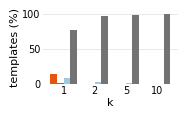

seifr, threshold: % of templates per strategy, and sampled fraction (median, min)
       index  skip-seq. scan  scan w/o LBs   FFT  median  min
param                                                        
0.600    0.0             0.0           3.4  96.6     1.0  1.0
0.700    0.0             0.0           8.6  91.4     1.0  1.0
0.800    0.0             0.0          18.6  81.4     1.0  1.0
0.900    0.0             0.0          39.7  60.3     1.0  1.0
0.950    0.0             0.0          83.7  16.3     1.0  1.0
0.990    0.0             0.0          98.0   2.0     1.0  1.0
0.999    0.0             0.0         100.0   0.0     1.0  1.0 



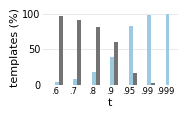

seifr, k: % of templates per strategy, and sampled fraction (median, min)
       index  skip-seq. scan  scan w/o LBs    FFT  median     min
param                                                            
1.0      0.0             0.0          28.9   71.1     1.0  0.1278
2.0      0.0             0.0           1.7   98.3     1.0  1.0000
5.0      0.0             0.0           0.0  100.0     1.0  1.0000
10.0     0.0             0.0           0.0  100.0     1.0  1.0000 



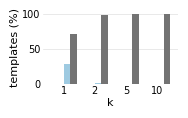

In [17]:
import re


def decisions(root):
    """One row per (template, node) decision of TREMOR, parsed from the run logs: the sampled candidate fraction, and
    whether the scan fallback computed the distances window by window or with FFTs."""
    rows = []
    for log in (EVALS / root / 'logs').glob('*tremor*.out'):
        text = log.read_text(errors='replace')
        run = re.search(r'\[job\] run_id=(\S+)', text).group(1)
        param = re.search(r'\.(th\d+p\d+|k\d+)\.', run).group(1)
        fft = {(node, query) for node, query in re.findall(r'\[Node (\d+)\] adaptive query (\d+): scan \S+ s or FFT \S+ s .* -> fft', text)}
        for node, query, fraction, decision in re.findall(
                r'\[Node (\d+)\] adaptive query (\d+): sampled candidate fraction ([\d.]+) -> (scan|leaf)', text):
            rows.append({'dataset': run.split('_')[0], 'channel': run.split('.')[1],
                         'workload': 'threshold' if param.startswith('th') else 'k',
                         'param': float(param[2:].replace('p', '.')) if param.startswith('th') else int(param[1:]),
                         'fraction': float(fraction), 'scan': decision == 'scan', 'fft': (node, query) in fft})
    return pd.DataFrame(rows, columns=['dataset', 'channel', 'workload', 'param', 'fraction', 'scan', 'fft'])


dec = decisions(f'sub_tremor_main_{TAG}')
dec = dec[dec.param.isin(THRESHOLDS + KS)]
# TREMOR's strategy follows from the sampled fraction (f = 1%, b = 5%; Section "Adaptive Search"), and the scan
# computes the distances with FFTs when they are predicted to be cheaper.
STRATEGY_NAMES = ['index', 'skip-seq. scan', 'scan w/o LBs', 'FFT']
STRATEGY_COLORS = [COLORS['TREMOR'], COLORS['SSS'], '#9ecae1', COLORS['DMASS-V3']]
legend_strip(STRATEGY_NAMES, STRATEGY_COLORS, 'strategies')
dec['strategy'] = pd.cut(dec.fraction, [-1, 0.01, 0.05, 2], labels=STRATEGY_NAMES[:3]).astype(str)
dec.loc[dec.fft, 'strategy'] = 'FFT'
for dataset in ['maule', 'seifr']:
    for param in ['threshold', 'k']:
        d = dec[(dec.dataset == dataset) & (dec.workload == param)]
        if d.empty:
            print(f'{dataset}, {param}: no decisions yet')
            continue
        share = d.groupby('param').strategy.value_counts(normalize=True).unstack().reindex(columns=STRATEGY_NAMES).fillna(0) * 100
        print(f'{dataset}, {param}: % of templates per strategy, and sampled fraction (median, min)')
        print(pd.concat([share.round(1), d.groupby('param').fraction.agg(['median', 'min']).round(4)], axis=1).to_string(), '\n')
        bar_plot(share, 't' if param == 'threshold' else 'k', 'templates (%)', f'adaptive_decisions_vs_{param}_{dataset}_4nodes',
                 STRATEGY_COLORS)


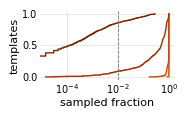

In [18]:
# Candidate fraction per template (Maule): the cumulative share of templates whose candidate fraction is below x.
d = dec[(dec.dataset == 'maule') & (dec.workload == 'threshold')]
fig, ax = plt.subplots()
for threshold, per_threshold in d.groupby('param'):
    x = np.sort(per_threshold.fraction)
    ax.step(x, np.arange(1, len(x) + 1) / len(x), where='post', color=THRESHOLD_COLORS[threshold])
ax.axvline(0.01, color=COLORS['DMASS-V3'], linestyle='--', linewidth=0.6)  # f: up to here, the index
ax.set_xscale('log')
ax.xaxis.set_major_locator(mticker.LogLocator(numticks=4))
ax.set_xlabel('sampled fraction')
ax.set_ylabel('templates')
ax.grid(axis='x', alpha=0.5)
fig.savefig(PLOTS / 'adaptive_candidate_fraction_cdf_maule_4nodes.pdf')
plt.show()


## Ablation: TREMOR's parameters
One parameter varies and the others keep their defaults (`experiments/ablation.slurm`): the scan fallback fraction $f$
(TREMOR scans when more than $f$ of the sampled subsequences pass the lower bound; $f=0$ always scans, $f=\infty$ never
does, i.e., index only), the lower-bound cut-off $b$ of the scan (the scan checks the lower bounds only when less than
$b$ of the sampled subsequences pass them), the leaf size, and the number of PAA segments. Three Maule channels of the
evaluation (ZE.G50S, XS.QC11, XS.QF17; 1.42 billion points), 4 nodes, full replication, 50 templates per channel, for
the settings where the parameters matter ($t = 0.99$, $t = 0.999$, $k = 1$). Every run returns the same answers.
The random walk (100M points, 20 templates of 256 points, 1 node; not in the paper, and its scripts are not part of
this repository) covers a series where the index prunes well.

runs per channel and repetition: {('XS_QC11_00_HHZ', 'ablation_20260930'): 44, ('XS_QC11_00_HHZ', 'ablation_20260930_rep2'): 41, ('XS_QC11_00_HHZ', 'ablation_20260930_rep3'): 41, ('XS_QC11_00_HHZ', 'ablation_20260930_scan'): 34, ('XS_QF17_00_HHE', 'ablation_20260930'): 44, ('XS_QF17_00_HHE', 'ablation_20260930_rep2'): 41, ('XS_QF17_00_HHE', 'ablation_20260930_rep3'): 41, ('XS_QF17_00_HHE', 'ablation_20260930_scan'): 34, ('ZE_G50S__HHN', 'ablation_20260930'): 44, ('ZE_G50S__HHN', 'ablation_20260930_rep2'): 41, ('ZE_G50S__HHN', 'ablation_20260930_rep3'): 41, ('ZE_G50S__HHN', 'ablation_20260930_scan'): 34} ; different answers: 0
query time, max / min over the repetitions (median over the configurations): 1.13
f: query time (s)
setting  t0.99  t0.999     k1
value                        
0         4.70    3.54   5.11
0.001     4.12    1.94   4.81
0.01      4.00    2.06   4.57
0.1       6.73    2.17   4.64
never    37.29    2.22  18.92
% of the templates answered through the index:
setting  

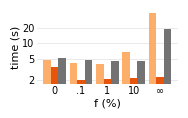

b: query time (s)
setting  t0.99  t0.999
value                 
0.01      3.37    1.72
0.05      4.07    2.02
0.2       5.35    1.97
0.5       5.48    1.98
1         6.65    2.08



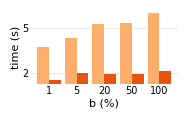

leaf: query time (s)
setting  t0.999    k1
value                
500        1.98  4.82
1000       1.85  4.69
2000       2.02  4.64
4000       1.89  4.05
8000       2.04  4.06
       index_time  index_gb
value                      
500         427.4      80.3
1000        240.2      69.7
2000        161.5      55.6
4000        107.6      56.2
8000        106.3      57.1



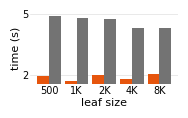

paa: query time (s)
setting  t0.999    k1
value                
4          3.02  4.97
8          5.15  5.00
16         2.02  4.64
       index_time  index_gb
value                      
4           169.9      25.1
8           185.7      36.2
16          161.5      55.6



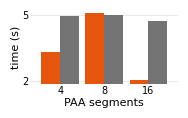

ablation_randomwalk_20260930
threshold  0.900  0.950  0.990  0.999
fallback                             
0           1.12   0.55   0.17   0.08
0.001       0.98   0.35   0.15   0.10
0.01        0.89   0.31   0.15   0.08
0.05        1.08   0.33   0.15   0.08
0.1         1.34   0.33   0.15   0.08
0.25        1.35   0.33   0.15   0.08
0.5         1.35   0.33   0.15   0.08
never       1.34   0.33   0.15   0.08
sss         1.09   0.65   0.62   0.63
threshold  0.900  0.950  0.990  0.999
fallback                             
0           1.25   1.76   1.14   1.02
0.001       1.10   1.13   1.00   1.20
0.01        1.00   1.00   1.00   1.00
0.05        1.21   1.06   1.01   1.01
0.1         1.51   1.04   1.01   1.01
0.25        1.51   1.05   1.01   1.00
0.5         1.52   1.05   1.01   1.04
never       1.50   1.07   1.00   0.97
sss         1.22   2.06   4.06   7.67
threshold  0.900  0.950  0.990  0.999
b                                    
0.00       0.791  0.295  0.153  0.085
0.01       0.792  0.3

In [19]:
ABL_CHANNELS = ['ZE_G50S__HHN', 'XS_QC11_00_HHZ', 'XS_QF17_00_HHE']
SETTINGS = {'t0.99': 't = 0.99', 't0.999': 't = 0.999', 'k1': 'k = 1'}
SETTING_COLORS = {'t0.99': LIGHT_ORANGE, 't0.999': COLORS['TREMOR'], 'k1': COLORS['DMASS-V3']}
legend_strip(SETTINGS.values(), SETTING_COLORS.values(), 'settings')
# parameter: x label, {value: tick label}; f and b in %
PARAMETERS = {'f': ('f (%)', {'0': '0', '0.001': '.1', '0.01': '1', '0.1': '10', 'never': '∞'}),
              'b': ('b (%)', {'0.01': '1', '0.05': '5', '0.2': '20', '0.5': '50', '1': '100'}),
              'leaf': ('leaf size', {'500': '500', '1000': '1K', '2000': '2K', '4000': '4K', '8000': '8K'}),
              'paa': ('PAA segments', {'4': '4', '8': '8', '16': '16'})}


def all_channels(values):
    """Sum over the channels; no value until every channel completed."""
    return values.sum() if len(values) == len(ABL_CHANNELS) else np.nan


# Repetitions: ablation_20260930, ablation_20260930_rep2, ...; every value is the median over the repetitions.
files = list(EVALS.glob('ablation_20260930*/ablation.*.csv'))
abl = pd.concat(pd.read_csv(f, dtype={'value': str}).assign(rep=f.parent.name) for f in files) if files else pd.DataFrame(
    columns=['channel', 'param', 'value', 'setting', 'query_time', 'index_time', 'index_gb', 'index', 'same_answers', 'rep'])
abl = abl[abl.param != 'warmup'].dropna(subset=['query_time'])  # failed runs have no time
print('runs per channel and repetition:', abl.groupby(['channel', 'rep']).size().to_dict(),
      '; different answers:', int((abl.same_answers == 0).sum()))
spread = abl.groupby(['channel', 'param', 'value', 'setting']).query_time.agg(['min', 'max', 'size'])
print('query time, max / min over the repetitions (median over the configurations):',
      round((spread['max'] / spread['min'])[spread['size'] > 1].median(), 2))
abl = abl.groupby(['channel', 'param', 'value', 'setting'], as_index=False)[['query_time', 'index_time', 'index_gb', 'index']].median()
for param, (xlabel, values) in PARAMETERS.items():
    d = abl[abl.param == param]
    settings = [s for s in SETTINGS if s in d.setting.unique()] or list(SETTINGS)
    table = d.pivot_table(index='value', columns='setting', values='query_time', aggfunc=all_channels, dropna=False)
    table = table.reindex(index=values, columns=settings).astype(float)
    print(f'{param}: query time (s)')
    print(table.round(2).to_string())
    if param == 'f':  # templates (per node) answered through the index
        share = d[d.value != 'never'].pivot_table(index='value', columns='setting', values='index', aggfunc='sum') / (50 * len(ABL_CHANNELS)) * 100
        print('% of the templates answered through the index:')
        print(share.reindex(index=[v for v in values if v != 'never'], columns=settings).round(0).to_string())
    if param in ['leaf', 'paa']:  # index construction (one build per setting: their median)
        build = d.groupby(['value', 'channel'])[['index_time', 'index_gb']].median().groupby(level=0).agg(
            index_time=('index_time', all_channels), index_gb=('index_gb', 'mean'))
        print(build.reindex(values).round(1).to_string())
    print()
    bar_plot(table.rename(index=values), xlabel, 'time (s)', f'ablation_{param}_maule_4nodes',
             [SETTING_COLORS[s] for s in settings], logy=True)

# Random walk (100M points, 20 templates of 256 points), 1 node, median of 2 runs: query time per f and threshold.
RW = EVALS / 'ablation_randomwalk_20260930'  # current binary; before: ablation_randomwalk_20260928
if not list(RW.glob('ablation.*.csv')):
    RW = EVALS / 'ablation_randomwalk_20260928'
print(RW.name)
rw = pd.concat(pd.read_csv(f, dtype={'fallback': str}) for f in RW.glob('ablation.*.csv'))
rw_time = rw.groupby(['fallback', 'threshold']).query_time.median().unstack()
print(rw_time.round(2).to_string())
print((rw_time / rw_time.loc['0.01']).round(2).to_string())

# The lower-bound cut-off b on the same random walk (PARAM=b, f = 0.01): query time (s, mean of two repetitions).
rw_b = pd.concat(pd.read_csv(f) for f in EVALS.glob('ablation_randomwalk_b_20261001/ablation.*.csv'))
print(rw_b.groupby(['fallback', 'threshold']).query_time.mean().unstack('threshold').rename_axis('b').round(3))


## Per-template times: templates answered with the index vs. with the scan
The same templates are answered with the index only, with the scan only (TREMOR with $f=0$),
and by SSS; TREMOR ($f=1\%$) tells which of the two it chose for every template and node. Maule uses the
thresholds where the index is chosen at all (0.99 and 0.999, 4 nodes); the random walk uses 0.9 to 0.999 (1 node).

In [20]:
PATTERN = r'\[Node (\d+)\] query (\d+): ([\d.]+) s \((\w+)\)'


def per_query_logs(logs):
    """One row per (template, node) from the per-query lines of the given {name: log file}."""
    return pd.DataFrame([{'run': name, 'node': int(node), 'query': int(query), 'seconds': float(seconds), 'how': how}
                         for name, log in logs.items()
                         for node, query, seconds, how in re.findall(PATTERN, log.read_text(errors='replace'))])


def eval_root_logs(root):
    """{run id: log file} of the TREMOR runs of an evaluation root."""
    logs = {}
    for log in (EVALS / root / 'logs').glob('*tremor*.out'):
        logs[re.search(r'\[job\] run_id=(\S+)', log.read_text(errors='replace')).group(1)] = log
    return logs


def per_template(sources, keys):
    """Join the per-template times of {column: DataFrame}; `choice` is TREMOR's decision."""
    table = sources['adaptive'].rename(columns={'how': 'choice', 'seconds': 'adaptive'})
    for column in [c for c in ['index', 'scan', 'SSS'] if c in sources]:
        table = table.merge(sources[column][keys + ['seconds']].rename(columns={'seconds': column}), on=keys)
    return table


def print_per_template(table):
    """Median seconds per template and node, by TREMOR's choice."""
    shown = [c for c in ['index', 'scan', 'SSS'] if c in table]
    print(table.groupby('choice')[shown + ['adaptive']].median().round(3).assign(
        templates=table.groupby('choice').size(),
        **{'SSS / adaptive (median)': (table.SSS / table.adaptive).groupby(table.choice).median().round(2),
           'SSS / index (median)': (table.SSS / table['index']).groupby(table.choice).median().round(2)}).to_string(), '\n')


# Maule, 4 nodes: one row per (run, node, template); run ids differ only in the evaluation root.
maule = {column: per_query_logs(eval_root_logs(root)) for column, root in
         [('adaptive', f'full_adaptive_{FULL}c'), ('index', f'full_simple_{FULL}'), ('SSS', f'full_sss_{FULL}')]}
maule = per_template(maule, ['run', 'node', 'query'])
print('Maule, thresholds 0.99 and 0.999, 4 nodes:')
print_per_template(maule)

# Random walk, 1 node: logs th<t>.f<fallback>.rep<r>.log (0.01: adaptive, never: index only, 0: scan only, sss: SSS).
RW = EVALS / 'ablation_randomwalk_20260928' / 'runs'
walk = {column: per_query_logs({log.name.replace(f'.f{f}.', '.'): log for log in RW.glob(f'th*.f{f}.rep*.log')})
        for column, f in [('adaptive', '0.01'), ('index', 'never'), ('scan', '0'), ('SSS', 'sss')]}
walk = per_template(walk, ['run', 'node', 'query'])
print('Random walk, thresholds 0.9 to 0.999, 1 node:')
print_per_template(walk)

Maule, thresholds 0.99 and 0.999, 4 nodes:
        index    SSS  adaptive  templates  SSS / adaptive (median)  SSS / index (median)
choice                                                                                  
index   0.027  0.224     0.027         25                     5.43                  5.73
scan    3.319  0.297     0.117        130                     2.59                  0.08 

Random walk, thresholds 0.9 to 0.999, 1 node:
        index   scan    SSS  adaptive  templates  SSS / adaptive (median)  SSS / index (median)
choice                                                                                         
index   0.007  0.007  0.031     0.007        144                     4.55                  4.37
scan    0.078  0.054  0.052     0.054         16                     0.96                  0.71 



## Templates with close matches: all competitors
The templates are catalog events cut from the waveforms, so many of them have a close match. For every template we take
the correlation of its best match (the 1-NN answer of the same template; all methods return the same answers) and
group the templates into *no close match* (< 0.99), *close* (0.99 - 0.999) and *near-identical* (> 0.999) matches.
For each workload (4 nodes, full replication: every template is answered by one node over the whole waveform) we
compare the median time per template of the methods. D-MASS logs no per-template time; its cost does not
depend on the template, so every template gets the mean time per template of its run. The second figure shows, per
template, TREMOR's speedup over SSS against how close the best match is, and whether the index or the scan
answered it. (Per-template joins use multi-node runs, where TREMOR keeps the template order.)

maule_k1_4nodes: median seconds per template by the correlation of the best match
            SSS  DMASS-V1  DMASS-V3  TREMOR  templates  TREMOR vs SSS  TREMOR vs DMASS-V1  TREMOR vs DMASS-V3
match                                                                                                        
<.99      0.377     2.836     0.325   0.168        247            2.2                16.8                 1.9
.99-.999  0.295     2.569     0.279   0.139        454            2.1                18.5                 2.0
>.999     0.344     4.116     0.355   0.123        271            2.8                33.4                 2.9 



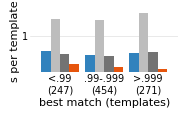

seifr_k1_4nodes: median seconds per template by the correlation of the best match
            SSS  DMASS-V1  DMASS-V3  TREMOR  templates  TREMOR vs SSS  TREMOR vs DMASS-V1  TREMOR vs DMASS-V3
match                                                                                                        
<.99      1.835     5.896     0.704   0.401         67            4.6                14.7                 1.8
.99-.999  1.803     5.933     0.704   0.397        258            4.5                14.9                 1.8
>.999     1.589     5.973     0.699   0.273         25            5.8                21.9                 2.6 



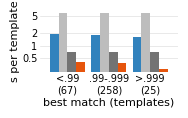

maule_th0.999_4nodes: median seconds per template by the correlation of the best match
            SSS  DMASS-V1  DMASS-V3  TREMOR  templates  TREMOR vs SSS  TREMOR vs DMASS-V1  TREMOR vs DMASS-V3
match                                                                                                        
<.99      0.218     3.384     0.410   0.016        247           13.4               207.0                25.1
.99-.999  0.206     2.685     0.382   0.035        454            5.8                76.0                10.8
>.999     0.266     4.290     0.484   0.099        271            2.7                43.4                 4.9 



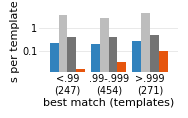

maule_th0.99_4nodes: median seconds per template by the correlation of the best match
            SSS  DMASS-V1  DMASS-V3  TREMOR  templates  TREMOR vs SSS  TREMOR vs DMASS-V1  TREMOR vs DMASS-V3
match                                                                                                        
<.99      0.245     2.947     0.447   0.089        247            2.8                33.1                 5.0
.99-.999  0.221     2.745     0.381   0.077        454            2.9                35.8                 5.0
>.999     0.320     4.283     0.577   0.109        271            2.9                39.2                 5.3 



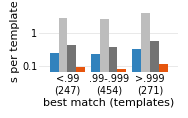

In [21]:
MATCH_BINS = [-1, 0.99, 0.999, 1.01]
MATCH_LABELS = ['<.99', '.99-.999', '>.999']


def full4(method, dataset):
    return runs[(runs.method == method) & (runs.dataset == dataset) & (runs.nodes == 4) & (runs.strategy == 'full')]


def best_match(dataset):
    """Correlation of every template's best match, keyed by (channel, template), from the k = 1 answers."""
    d = full4('TREMOR', dataset)
    d = d[d.k == 1]
    parts = [pd.read_csv(output + '.csv', skipinitialspace=True).query('k == 1').assign(channel=channel)
             for channel, output in zip(d.channel, d.output)]
    if not parts:
        return pd.Series(name='best', dtype=float, index=pd.MultiIndex.from_tuples([], names=['channel', 'query']))
    best = pd.concat(parts).rename(columns={'tID': 'query', 'corr': 'best'})
    return best.set_index(['channel', 'query']).best


def template_times(method, dataset, param, value):
    """Seconds per template (and how TREMOR answered it), keyed by (channel, template)."""
    d = full4(method, dataset)
    d = d[d[param] == value]
    logs, channel_of = {}, dict(zip(d.run, d.channel))
    for root in d.root.unique():
        logs.update({run: log for run, log in eval_root_logs(root).items() if run in channel_of})
    q = per_query_logs(logs)
    if q.empty:
        return pd.DataFrame(columns=[method, 'how'], index=pd.MultiIndex.from_tuples([], names=['channel', 'query']))
    q['channel'] = q.run.map(channel_of)
    q = q.groupby(['channel', 'query']).agg(seconds=('seconds', 'max'), how=('how', 'first'))
    return q.rename(columns={'seconds': method})


def close_match_table(dataset, param, value):
    table = best_match(dataset).to_frame()
    for method in ['SSS', 'TREMOR']:
        t = template_times(method, dataset, param, value)
        table = table.join(t[[method]] if method != 'TREMOR' else t, how='left')
    table = table.dropna(subset=['best', 'SSS', 'TREMOR'])
    for method in ['DMASS-V1', 'DMASS-V3']:
        dmass = full4(method, dataset)
        dmass = dmass[dmass[param] == value]
        per_template = (dmass.query_time / dmass.queries).groupby(dmass.channel).mean()
        table[method] = table.index.get_level_values('channel').map(per_template)
    table['match'] = pd.cut(table.best, MATCH_BINS, labels=MATCH_LABELS)
    return table


def plot_close_matches(dataset, param, value):
    table = close_match_table(dataset, param, value)
    tag = f'{dataset}_{label(param, value)}_4nodes'
    if table.empty:
        print(f'{tag}: no results yet')
        return
    medians = table.groupby('match', observed=True)[METHODS].median()
    medians = medians.loc[:, medians.notna().any() | medians.columns.isin(PENDING)]
    counts = table.groupby('match', observed=True).size()
    print(f'{tag}: median seconds per template by the correlation of the best match')
    speedups = {f'TREMOR vs {m}': (medians[m] / medians['TREMOR']).round(1) for m in ['SSS', 'DMASS-V1', 'DMASS-V3'] if m in medians}
    print(medians.round(3).assign(templates=counts, **speedups).to_string(), '\n')
    medians.index = [f'{b}\n({n})' for b, n in zip(medians.index, counts)]
    bar_plot(medians, 'best match (templates)', 's per template', f'close_matches_time_per_template_{tag}',
             [COLORS[m] for m in medians.columns], logy=True)


for dataset, param, value in [('maule', 'k', 1), ('seifr', 'k', 1), ('maule', 'threshold', 0.999), ('maule', 'threshold', 0.99)]:
    plot_close_matches(dataset, param, value)


## Time per template: index, scan, or FFT
One point per template (4 nodes, full replication: each template is answered by one node over the whole waveform; all
thresholds, or all $k$, of a dataset together). x: the time of the skip-sequential scan (SSS) for the template, i.e.,
how hard the template is for a scan; y: TREMOR's time for the same template; both per subsequence of the channel, so
that channels of different lengths are comparable. The color is the strategy with which TREMOR answered the template
(index, early-abandoning scan with or without lower bounds, FFT); points below the diagonal are faster with TREMOR.

per_template_time_maule_threshold_4nodes (6804 points; ns per subsequence, medians); TREMOR slower than SSS for 4.0% of the templates, by more than 20% for 1.8%
       templates    SSS  TREMOR  % of templates  SSS q0.05  TREMOR q0.05  SSS q0.95  TREMOR q0.95  speedup (median)  speedup q0.95
how                                                                                                                               
index        924  0.304   0.089          13.580      0.293         0.010      0.478         0.342             3.687         30.820
scan        3730  0.425   0.150          54.821      0.329         0.109      1.145         0.485             2.979          4.121
fft         2150  0.605   0.241          31.599      0.481         0.226      1.072         0.489             2.424          3.738 



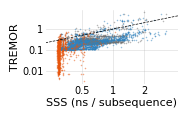

per_template_time_maule_k_4nodes (3888 points; ns per subsequence, medians); TREMOR slower than SSS for 1.3% of the templates, by more than 20% for 0.7%
       templates    SSS  TREMOR  % of templates  SSS q0.05  TREMOR q0.05  SSS q0.95  TREMOR q0.95  speedup (median)  speedup q0.95
how                                                                                                                               
index        137  0.388   0.064           3.524      0.306         0.007      0.679         0.395             5.964         50.697
scan         123  0.445   0.180           3.164      0.328         0.113      3.114         1.438             2.963          5.402
fft         3628  0.682   0.242          93.313      0.383         0.228      1.611         0.497             2.620          4.736 



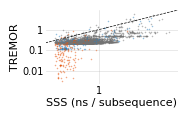

per_template_time_seifr_threshold_4nodes (2450 points; ns per subsequence, medians); TREMOR slower than SSS for 0.0% of the templates, by more than 20% for 0.0%
       templates    SSS  TREMOR  % of templates  SSS q0.05  TREMOR q0.05  SSS q0.95  TREMOR q0.95  speedup (median)  speedup q0.95
how                                                                                                                               
index        NaN    NaN     NaN             NaN        NaN           NaN        NaN           NaN               NaN            NaN
scan      1232.0  0.663   0.115          50.286      0.507         0.108      0.810         0.219             5.228          6.317
fft       1218.0  1.283   0.249          49.714      0.748         0.239      1.996         0.298             5.053          7.989 



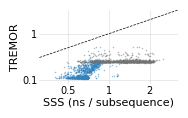

per_template_time_seifr_k_4nodes (1400 points; ns per subsequence, medians); TREMOR slower than SSS for 0.0% of the templates, by more than 20% for 0.0%
       templates    SSS  TREMOR  % of templates  SSS q0.05  TREMOR q0.05  SSS q0.95  TREMOR q0.95  speedup (median)  speedup q0.95
how                                                                                                                               
index        NaN    NaN     NaN             NaN        NaN           NaN        NaN           NaN               NaN            NaN
scan       107.0  1.081   0.126           7.643      0.707         0.114      1.766         0.173             8.367         14.258
fft       1293.0  3.099   0.264          92.357      0.792         0.248      3.825         0.315            11.627         14.587 



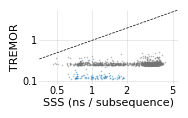

In [22]:
ANSWERED = {'index': ('index', COLORS['TREMOR']), 'scan': ('scan', COLORS['SSS']), 'fft': ('FFT', COLORS['DMASS-V3'])}
legend_strip([name for name, _ in ANSWERED.values()], [color for _, color in ANSWERED.values()], 'answered_by')


def per_template(dataset, param):
    """One row per template and threshold (or k): ns per subsequence of SSS and of TREMOR, and TREMOR's strategy."""
    parts = []
    for value in (THRESHOLDS if param == 'threshold' else KS):
        t = template_times('TREMOR', dataset, param, value).join(template_times('SSS', dataset, param, value)[['SSS']], how='inner')
        parts.append(t.assign(value=value))
    table = pd.concat(parts).reset_index()
    d = full4('TREMOR', dataset).drop_duplicates('channel').set_index('channel')
    subsequences = table.channel.map(d.samples - d.window + 1)
    for method in ['SSS', 'TREMOR']:
        table[method] = table[method] / subsequences * 1e9
    return table


def plot_per_template(dataset, param):
    table = per_template(dataset, param)
    name = f'per_template_time_{dataset}_{param}_4nodes'
    speedup = table.SSS / table.TREMOR
    summary = table.groupby('how').agg(templates=('how', 'size'), SSS=('SSS', 'median'), TREMOR=('TREMOR', 'median'))
    summary['% of templates'] = summary.templates / len(table) * 100
    for q in [0.05, 0.95]:  # spread of the times and of the speedup
        summary[f'SSS q{q:g}'] = table.groupby('how').SSS.quantile(q)
        summary[f'TREMOR q{q:g}'] = table.groupby('how').TREMOR.quantile(q)
    summary['speedup (median)'] = speedup.groupby(table.how).median()
    summary['speedup q0.95'] = speedup.groupby(table.how).quantile(0.95)
    print(name, f'({len(table)} points; ns per subsequence, medians); TREMOR slower than SSS for',
          f'{(speedup < 1).mean() * 100:.1f}% of the templates, by more than 20% for {(speedup < 1 / 1.2).mean() * 100:.1f}%')
    print(summary.reindex(ANSWERED).round(3).to_string(), '\n')
    fig, ax = plt.subplots()
    for how in ['fft', 'scan', 'index']:  # the index on top
        d = table[table.how == how]
        ax.scatter(d.SSS, d.TREMOR, s=1.2, color=ANSWERED[how][1], alpha=0.5, linewidths=0, rasterized=True)
    ax.set_xscale('log')
    ax.set_yscale('log')
    limits = {ax.xaxis: (table.SSS.min() / 1.3, table.SSS.max() * 1.3),
              ax.yaxis: (table.TREMOR.min() / 1.3, max(table.TREMOR.max(), table.SSS.max()) * 1.3)}  # the diagonal in view
    ax.set_xlim(*limits[ax.xaxis])
    ax.set_ylim(*limits[ax.yaxis])
    ax.axline((1, 1), (10, 10), color='black', linestyle='--', linewidth=0.5)  # equal times
    for axis, (low, high) in limits.items():  # plain numbers, in 1-2-5 steps on a short axis
        axis.set_major_locator(mticker.LogLocator(subs=(1.0,) if high / low > 30 else (1.0, 2.0, 5.0)))
        axis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:g}'))
        axis.set_minor_formatter(mticker.NullFormatter())
    ax.grid(axis='x', alpha=0.5)
    ax.set_xlabel('SSS (ns / subsequence)')
    ax.set_ylabel('TREMOR')
    fig.savefig(PLOTS / f'{name}.pdf', dpi=600)
    plt.show()


for dataset in ['maule', 'seifr']:
    for param in ['threshold', 'k']:
        plot_per_template(dataset, param)

## Does the index help? (Maule)
The same templates answered with each strategy alone and by TREMOR, in the same job (`experiments/ablation.slurm` with
`PARAMS="f scan"`: three Maule channels, 150 templates, 4 nodes, full replication; $t = 0.99$, $t = 0.999$, $k = 1$):
the index only, the skip-sequential scan (SSS), and the early-abandoning scan without lower bounds. For every template:
the *candidate fraction* (the share of the sampled subsequences whose lower bound passes, which is what TREMOR looks at
to choose its strategy; $f = 1\%$, $b = 5\%$), and the speedup of the index over the faster of the two scans. The color
is TREMOR's choice for the template. The bars compare the total times over the templates. Until the job with both
scans finishes, only the skip-sequential scan is available (the SSS run of the evaluation).

The paper reports these numbers in its text (no figure). Last, on all Maule channels: TREMOR against TREMOR that never
searches its index and takes no first $k$-NN bound from it (a debugging option that is not part of this repository), over the
channels that both completed.


t0.8 ablation_20260930_scan


/tmp/ipykernel_2436980/320931938.py:72: RuntimeWarning: invalid value encountered in scalar divide
  f"({selective.scan.sum() / selective['index'].sum():.2f}x); TREMOR's choice is the faster of index and scan for",


t0.8: 150 templates; candidate fraction <= 1%: 0 templates, index 0.00 s vs scan 0.00 s (nanx); TREMOR's choice is the faster of index and scan for 100% of the templates
          templates  speedup  max_speedup  min_speedup  skip-seq. scan (s)  scan w/o LBs (s)  index (s)  TREMOR (s)  TREMOR w/o index (s)  scan w/o LBs faster (%)
fraction                                                                                                                                                          
> 5%            150     0.02         0.04         0.01               37.77             14.83     652.07       17.82                 18.17                    100.0
TREMOR chooses: {'scan w/o LBs': 76, 'FFT': 74} 



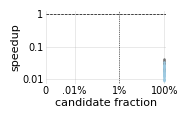

t0.9 ablation_20260930_scan
t0.9: 150 templates; candidate fraction <= 1%: 0 templates, index 0.00 s vs scan 0.00 s (nanx); TREMOR's choice is the faster of index and scan for 100% of the templates
          templates  speedup  max_speedup  min_speedup  skip-seq. scan (s)  scan w/o LBs (s)  index (s)  TREMOR (s)  TREMOR w/o index (s)  scan w/o LBs faster (%)
fraction                                                                                                                                                          
> 5%            150     0.02         0.04         0.01               33.75             10.28     484.49        14.7                  14.5                    100.0
TREMOR chooses: {'scan w/o LBs': 104, 'FFT': 46} 



/tmp/ipykernel_2436980/320931938.py:72: RuntimeWarning: invalid value encountered in scalar divide
  f"({selective.scan.sum() / selective['index'].sum():.2f}x); TREMOR's choice is the faster of index and scan for",


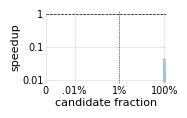

t0.99 ablation_20260930_scan
t0.99: 150 templates; candidate fraction <= 1%: 37 templates, index 4.03 s vs scan 2.10 s (0.52x); TREMOR's choice is the faster of index and scan for 79% of the templates
            templates  speedup  max_speedup  min_speedup  skip-seq. scan (s)  scan w/o LBs (s)  index (s)  TREMOR (s)  TREMOR w/o index (s)  scan w/o LBs faster (%)
fraction                                                                                                                                                            
(0, 0.1%]          14     0.80         2.16         0.31                2.66              0.85       1.10        1.17                  3.09                    100.0
(0.1%, 1%]         23     0.42         0.87         0.18                4.06              1.25       2.93        3.21                  4.26                    100.0
(1%, 5%]           13     0.27         0.38         0.11                2.95              0.88       3.69        3.52                  3.08

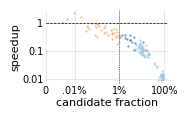

t0.999 ablation_20260930_scan
t0.999: 150 templates; candidate fraction <= 1%: 134 templates, index 4.95 s vs scan 7.50 s (1.52x); TREMOR's choice is the faster of index and scan for 76% of the templates
            templates  speedup  max_speedup  min_speedup  skip-seq. scan (s)  scan w/o LBs (s)  index (s)  TREMOR (s)  TREMOR w/o index (s)  scan w/o LBs faster (%)
fraction                                                                                                                                                            
0                  76     3.99        15.72         0.63               13.60              4.53       1.48        1.44                 14.69                    100.0
(0, 0.1%]          44     1.11         5.32         0.32                7.91              2.53       2.24        2.39                  8.22                    100.0
(0.1%, 1%]         14     0.35         0.71         0.18                1.30              0.44       1.22        1.22                  1

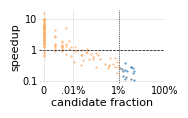

k1 ablation_20260930_scan
k1: 150 templates; candidate fraction <= 1%: 30 templates, index 2.20 s vs scan 3.01 s (1.37x); TREMOR's choice is the faster of index and scan for 65% of the templates
            templates  speedup  max_speedup  min_speedup  skip-seq. scan (s)  scan w/o LBs (s)  index (s)  TREMOR (s)  TREMOR w/o index (s)  scan w/o LBs faster (%)
fraction                                                                                                                                                            
0                  13     7.00        13.97         0.67                3.15              1.21       0.30        0.28                  1.74                    100.0
(0, 0.1%]           8     1.22         4.11         0.44                1.67              0.71       0.53        0.45                  1.07                    100.0
(0.1%, 1%]          9     0.75         1.38         0.37                2.58              1.09       1.37        1.44                  1.57      

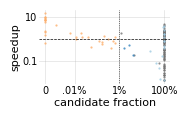

         skip-seq. scan  scan w/o LBs   index  TREMOR   scan  TREMOR w/o index  skip-seq. scan / TREMOR  scan w/o LBs / TREMOR  index / TREMOR  scan / TREMOR  TREMOR w/o index / TREMOR
t=0.8             37.77         14.83  652.07   17.82  14.83             18.17                     2.12                   0.83           36.59           0.83                       1.02
t=0.9             33.75         10.28  484.49   14.70  10.28             14.50                     2.30                   0.70           32.97           0.70                       0.99
t=0.99            26.69          7.80  146.71   14.27   7.80             17.20                     1.87                   0.55           10.28           0.55                       1.21
t=0.999           24.22          8.01    7.61    6.49   8.01             25.95                     3.73                   1.24            1.17           1.24                       4.00
k=1               34.89         15.16   69.13   17.70  15.16             20

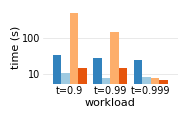

method      SSS  TREMOR  TREMOR w/o index  channels  w/o index / TREMOR
setting                                                                
k=1       84.82   40.13             46.50        20                1.16
k=10     133.78   45.15             46.50        20                1.03
k=2      120.03   46.07             47.43        20                1.03
k=5      131.68   47.87             45.97        20                0.96
t=0.99    66.24   26.82             33.54        20                1.25
t=0.999   57.93   20.49             63.62        20                3.10
t0.8 index vs SSS; TREMOR chooses the faster for 100% of the templates
          size  median   max   min
fraction                          
> 5%       150    0.06  0.13  0.02 

t0.9 index vs SSS; TREMOR chooses the faster for 100% of the templates
          size  median   max   min
fraction                          
> 5%       150    0.07  0.15  0.04 

t0.99 index vs SSS; TREMOR chooses the faster for 94% of the templat

In [23]:
RUN_NAME = '{channel}.{setting}.f{f}.b0.05.leaf2000.paa16.log'
PANELS = ['t0.9', 't0.99', 't0.999']  # the workloads of the paper's figure


def runs_of(setting):
    """The directory with the runs of a workload for all channels: the job with the index, the scans and TREMOR
    (ablation_20260930_scan); before it finishes, the first repetition of the ablation (no scans); else None."""
    for directory in [EVALS / 'ablation_20260930_scan' / 'runs', EVALS / 'ablation_20260930' / 'runs']:
        if all((directory / RUN_NAME.format(channel=c, setting=setting, f=f)).exists() for c in ABL_CHANNELS
               for f in (['never', '0.01', 'ss'] if 'scan' in directory.parent.name else ['never', '0.01'])):
            return directory
SETTING_RUNS = {'t0.8': ('threshold', 0.8), 't0.9': ('threshold', 0.9), 't0.99': ('threshold', 0.99), 't0.999': ('threshold', 0.999),
                'k1': ('k', 1)}  # the workloads with runs are shown
# One legend for the points (TREMOR's choice for the template) and the bars (each strategy alone, and TREMOR).
INDEX_HELP = {'index': LIGHT_ORANGE, 'skip-seq. scan': COLORS['SSS'], 'scan w/o LBs': '#9ecae1', 'FFT': COLORS['DMASS-V3'],
              'TREMOR': COLORS['TREMOR']}
legend_strip(INDEX_HELP, INDEX_HELP.values(), 'index_help')
ALONE = ['skip-seq. scan', 'scan w/o LBs', 'index', 'TREMOR']  # the bars


def seconds_per_template(log):
    return per_query_logs({'run': log}).groupby('query').agg(seconds=('seconds', 'max'), how=('how', 'first'))


def index_vs_scan(setting):
    """One row per template of the three channels: candidate fraction, seconds with the index only, with each scan,
    and with TREMOR, and TREMOR's choice."""
    parts, directory = [], runs_of(setting)
    for channel in ABL_CHANNELS:
        log = lambda f: directory / RUN_NAME.format(channel=channel, setting=setting, f=f)
        tremor = seconds_per_template(log('0.01'))
        fractions = re.findall(r'adaptive query (\d+): sampled candidate fraction ([\d.]+)', log('0.01').read_text(errors='replace'))
        table = pd.DataFrame({'fraction': pd.Series({int(q): float(c) for q, c in fractions}), 'TREMOR': tremor.seconds,
                              'how': tremor.how, 'index': seconds_per_template(log('never')).seconds})
        if log('sss').exists():
            table['skip-seq. scan'] = seconds_per_template(log('sss')).seconds
            table['scan w/o LBs'] = seconds_per_template(log('ss')).seconds
            table['TREMOR w/o index'] = seconds_per_template(log('noindex')).seconds
        else:
            table['skip-seq. scan'] = template_times('SSS', 'maule', *SETTING_RUNS[setting]).loc[channel].SSS
            table['scan w/o LBs'] = table['TREMOR w/o index'] = np.nan
        parts.append(table.assign(channel=channel))
    table = pd.concat(parts).dropna(subset=['fraction', 'TREMOR', 'index', 'skip-seq. scan'])
    # TREMOR's choice: the index up to f = 1%; a scan with lower bounds below b = 5%, without them above; or FFTs.
    table['choice'] = np.select([table.how == 'fft', table.how == 'index', table.fraction < 0.05],
                                ['FFT', 'index', 'skip-seq. scan'], 'scan w/o LBs')
    table['scan'] = table[['skip-seq. scan', 'scan w/o LBs']].min(axis=1)  # the faster scan for the template
    return table


ZERO = 5e-6  # where a candidate fraction of 0 is drawn (the smallest non-zero fraction of the sample is 1.5e-5)
totals = {}
for setting, (param, value) in SETTING_RUNS.items():
    name = f'index_speedup_vs_candidate_fraction_maule_{setting}_4nodes'
    if runs_of(setting) is None:
        if setting in PANELS:
            pending_figure(name)
            totals[f't={value:g}'] = pd.Series(dtype=float)
        continue
    print(setting, runs_of(setting).parent.name)
    table = index_vs_scan(setting)
    table['speedup'] = table.scan / table['index']
    totals[f"{'t' if param == 'threshold' else 'k'}={value:g}"] = table[ALONE + ['scan', 'TREMOR w/o index']].sum(min_count=1)
    bins = pd.cut(table.fraction, [-1, 0, 1e-3, 1e-2, 5e-2, 2], labels=['0', '(0, 0.1%]', '(0.1%, 1%]', '(1%, 5%]', '> 5%'])
    summary = table.groupby(bins, observed=True).agg(templates=('speedup', 'size'), speedup=('speedup', 'median'),
                                                     max_speedup=('speedup', 'max'), min_speedup=('speedup', 'min'))
    summary = summary.join(table.groupby(bins, observed=True)[ALONE + ['TREMOR w/o index']].sum(min_count=1).add_suffix(' (s)'))
    summary['scan w/o LBs faster (%)'] = (table['scan w/o LBs'] < table['skip-seq. scan']).groupby(bins, observed=True).mean() * 100
    selective = table[table.fraction <= 0.01]
    print(f'{setting}: {len(table)} templates; candidate fraction <= 1%: {len(selective)} templates,',
          f"index {selective['index'].sum():.2f} s vs scan {selective.scan.sum():.2f} s",
          f"({selective.scan.sum() / selective['index'].sum():.2f}x); TREMOR's choice is the faster of index and scan for",
          f"{((table.how == 'index') == (table.speedup > 1)).mean() * 100:.0f}% of the templates")
    print(summary.round(2).to_string())
    print('TREMOR chooses:', table.choice.value_counts().to_dict(), '\n')
    fig, ax = plt.subplots()
    for choice in ['FFT', 'scan w/o LBs', 'skip-seq. scan', 'index']:
        d = table[table.choice == choice]
        ax.scatter(d.fraction.clip(lower=ZERO), d.speedup, s=2.5, color=INDEX_HELP[choice], alpha=0.8, linewidths=0)
    ax.axhline(1, color='black', linestyle='--', linewidth=0.5)   # above: the index is faster
    ax.axvline(0.01, color='black', linestyle=':', linewidth=0.5)  # f: TREMOR uses the index up to here
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xticks([ZERO, 1e-4, 1e-2, 1], ['0', '.01%', '1%', '100%'])
    ax.xaxis.set_minor_locator(mticker.NullLocator())
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:g}'))
    ax.grid(axis='x', alpha=0.5)
    ax.set_xlabel('candidate fraction')
    ax.set_ylabel('speedup')
    fig.savefig(PLOTS / f'{name}.pdf')
    plt.show()

totals = pd.DataFrame(totals).T.reindex(columns=ALONE + ['scan', 'TREMOR w/o index'])
print(totals.round(2).assign(**{f'{c} / TREMOR': (totals[c] / totals.TREMOR).round(2) for c in totals.columns if c != 'TREMOR'}).to_string())
bar_plot(totals.loc[[f't={SETTING_RUNS[s][1]:g}' for s in PANELS], ALONE], 'workload', 'time (s)', 'index_vs_scan_total_maule_4nodes',
         [INDEX_HELP[c] for c in ALONE], logy=True)

# TREMOR with and without its index, on all Maule channels (4 nodes, full replication).
noindex = load_runs({f'sub_noindex_index_{TAG}': 'TREMOR w/o index'})
d = pd.concat([runs[runs.root.isin([f'sub_tremor_main_{TAG}', f'sub_sss_main_{TAG}'])], noindex])
d = d[d.dataset == 'maule'].assign(setting=lambda d: np.where(d.k.notna(), 'k=' + d.k.map('{:g}'.format), 't=' + d.threshold.map('{:g}'.format)))
d = d.pivot_table(index=['setting', 'channel'], columns='method', values='query_time').dropna(subset=['TREMOR', 'TREMOR w/o index'])
with_without = d.groupby('setting').sum().assign(channels=d.groupby('setting').size())
with_without['w/o index / TREMOR'] = with_without['TREMOR w/o index'] / with_without.TREMOR
print(with_without.round(2).to_string())

# The paper compares the index with SSS only: per template, SSS time / index-only time by candidate fraction, and how
# often TREMOR's choice (index or not) matches the faster of the two.
for setting in ['t0.8', 't0.9', 't0.99', 't0.999', 'k1']:
    table = index_vs_scan(setting)
    table['speedup'] = table['skip-seq. scan'] / table['index']
    bins = pd.cut(table.fraction, [-1, 0, 1e-3, 1e-2, 5e-2, 2], labels=['0', '(0, 0.1%]', '(0.1%, 1%]', '(1%, 5%]', '> 5%'])
    print(setting, 'index vs SSS; TREMOR chooses the faster for',
          f"{((table.how == 'index') == (table.speedup > 1)).mean() * 100:.0f}% of the templates")
    print(table.groupby(bins, observed=True).speedup.agg(['size', 'median', 'max', 'min']).round(2).to_string(), '\n')


## Optimization breakdown
The same templates on one node (Maule ZE.GC2S, 10 templates; SeiFR RD.EPF, 5 templates), answered by each optimization
step of TREMOR (`experiments/optimization_breakdown.slurm`, not part of this repository): s0 the first TREMOR; s1 persistent pinned query workers and
reused buffers; s2 two-pass leaf refinement; s3 $k$-NN first bound from the template's leaf and a $(2k-1)$-window bound set;
s4 the skip-sequential scan fallback; s5 skipping useless lower bounds; s6 the FFT fallback (TREMOR). s3b (useless bounds skipped in the
leaves of the index-only search) is not a step of TREMOR and is only printed. All steps return the same answers.

index only, useless leaf bounds skipped (s): {1.0: 6.65, 2.0: 124.48, 5.0: 128.57, 10.0: 130.58, 100.0: 135.76}
maule, k: query time (s), and speedup of each step over the first TREMOR and over SSS
step   s0_baseline  s1_workers  s2_twopass  s3_knnseed  s4_fallback  s5_adaptive  s6_fft   sss  vs s0: s0_baseline  vs s0: s1_workers  vs s0: s2_twopass  vs s0: s3_knnseed  vs s0: s4_fallback  vs s0: s5_adaptive  vs s0: s6_fft  vs SSS: s0_baseline  vs SSS: s1_workers  vs SSS: s2_twopass  vs SSS: s3_knnseed  vs SSS: s4_fallback  vs SSS: s5_adaptive  vs SSS: s6_fft
value                                                                                                                                                                                                                                                                                                                                                                        
1.0         123.01      123.09      122.76        6.58         1.78   

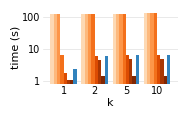

index only, useless leaf bounds skipped (s): {0.6: 90.91, 0.7: 69.63, 0.8: 49.44, 0.9: 33.56, 0.95: 26.43, 0.99: 9.13, 0.999: 0.32}
maule, th: query time (s), and speedup of each step over the first TREMOR and over SSS
step   s0_baseline  s1_workers  s2_twopass  s4_fallback  s5_adaptive  s6_fft   sss  vs s0: s0_baseline  vs s0: s1_workers  vs s0: s2_twopass  vs s0: s4_fallback  vs s0: s5_adaptive  vs s0: s6_fft  vs SSS: s0_baseline  vs SSS: s1_workers  vs SSS: s2_twopass  vs SSS: s4_fallback  vs SSS: s5_adaptive  vs SSS: s6_fft
value                                                                                                                                                                                                                                                                                                                     
0.600        93.11       93.78       92.17         4.71         3.04    1.44  4.71                 1.0                1.0                1.0           

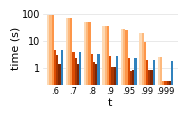

index only, useless leaf bounds skipped (s): {1.0: 45.98, 2.0: 184.06, 5.0: 227.22, 10.0: 259.57, 100.0: 289.34}
seifr, k: query time (s), and speedup of each step over the first TREMOR and over SSS
step   s0_baseline  s1_workers  s2_twopass  s3_knnseed  s4_fallback  s5_adaptive  s6_fft    sss  vs s0: s0_baseline  vs s0: s1_workers  vs s0: s2_twopass  vs s0: s3_knnseed  vs s0: s4_fallback  vs s0: s5_adaptive  vs s0: s6_fft  vs SSS: s0_baseline  vs SSS: s1_workers  vs SSS: s2_twopass  vs SSS: s3_knnseed  vs SSS: s4_fallback  vs SSS: s5_adaptive  vs SSS: s6_fft
value                                                                                                                                                                                                                                                                                                                                                                         
1.0         177.25      177.70      174.17       47.32         3.68

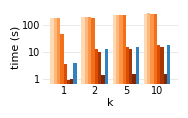

In [24]:
STEPS = {'s0_baseline': 'first', 's1_workers': '+workers', 's2_twopass': '+two-pass', 's3_knnseed': '+kNN bound',
         's4_fallback': '+fallback', 's5_adaptive': '+skip LBs', 's6_fft': '+FFT', 'sss': 'SSS'}
STEP_COLORS = [plt.cm.Oranges(0.2 + 0.8 * i / 6) for i in range(7)] + [COLORS['SSS']]
legend_strip(STEPS.values(), STEP_COLORS, 'breakdown', ncol=4)

brk = pd.concat(pd.read_csv(f) for f in sorted((EVALS / 'breakdown_20260929').glob('breakdown.*.csv')))
brk = brk.drop_duplicates(['dataset', 'param', 'value', 'step'], keep='last')  # latest job wins
assert brk.same_answers.all(), 'optimization steps disagree'
for (dataset, param), d in brk.groupby(['dataset', 'param']):
    table = d.pivot_table(index='value', columns='step', values='query_time')
    if 's3b_skipbounds' in table:  # index only, with useless bounds skipped in the leaves (not a step of TREMOR)
        print('index only, useless leaf bounds skipped (s):', table['s3b_skipbounds'].round(2).to_dict())
    steps = [s for s in STEPS if not (param == 'th' and s == 's3_knnseed')]  # the k-NN bound does not apply to thresholds
    table = table.reindex(columns=steps).dropna(axis=1, how='all')
    table = table[table.index.isin(THRESHOLDS if param == 'th' else KS)]
    print(f'{dataset}, {param}: query time (s), and speedup of each step over the first TREMOR and over SSS')
    tremor = [s for s in table.columns if s != 'sss']
    print(pd.concat([table.round(2), table[tremor].rtruediv(table['s0_baseline'], axis=0).add_prefix('vs s0: ').round(1),
                     table[tremor].rtruediv(table['sss'], axis=0).add_prefix('vs SSS: ').round(2)], axis=1).to_string(), '\n')
    xlabel = 't' if param == 'th' else 'k'
    bar_plot(table.rename(columns=STEPS), xlabel, 'time (s)', f'optimization_breakdown_{dataset}_{param}_1node',
             [STEP_COLORS[list(STEPS).index(s)] for s in table.columns], logy=True)


## Numbers in the paper

Every number of the evaluation (Section 4 of `paper/main.tex`, and the abstract, contributions, and conclusion that
repeat them), recomputed here from the runs, formatted as in the paper, and looked up in the text of the paper (when its LaTeX
source is at `../paper/main.tex`; otherwise the numbers are only printed):
`OK` means that the paper contains exactly this text, `NOT IN PAPER` that it does not (the paper must be updated).
Formats: speedups and ratios with one decimal below 10 and none above; times in seconds with three significant digits.


In [25]:
import json
import re
PAPER_TEX = Path('../paper/main.tex')  # the LaTeX source of the paper, if present
PAPER = re.sub(r'\\new\{([^{}]*)\}', r'\1', PAPER_TEX.read_text()) if PAPER_TEX.exists() else None  # without \new{} marks
checked = []


def x(v):
    """A speedup or ratio as in the paper: one decimal below 10, none above."""
    return f'{v:.1f}' if round(v, 1) < 10 else f'{v:.0f}'


def rng(values):
    values = list(values)
    return f'{x(min(values))}--{x(max(values))}'


def sec(v):
    """Seconds as in the paper: three significant digits."""
    return f'{v:.1f}' if round(v, 1) < 100 else f'{v:.0f}'


def claim(text):
    if PAPER is None:
        print(text)
        return
    checked.append(text in PAPER)
    print(('OK            ' if text in PAPER else 'NOT IN PAPER  ') + text)


BASELINES = ['SSS', 'DMASS-V3', 'DMASS-V1']


def cat(*tables):
    """Concatenation of the tables of total() (without their attrs, which pandas cannot compare)."""
    parts = []
    for t in tables:
        t = t.copy()
        t.attrs = {}
        parts.append(t)
    return pd.concat(parts)
speedup = lambda t, m: t[m] / t['TREMOR']

# Table 1: the datasets
print('Table 1 and Section 4.1')
ch = runs.groupby(['dataset', 'channel']).agg(samples=('samples', 'first'), queries=('queries', 'first'), window=('window', 'first'))
for dataset, label in [('maule', 'Maule'), ('seifr', 'SeiFR')]:
    c = ch.loc[dataset]
    print(f'  {label}: {len(c)} channels, {c.samples.min():,} to {c.samples.max():,} points per channel, '
          f'{c.samples.sum():,} points ({4 * c.samples.sum() / 1e9:.1f} GB), {c.queries.sum()} templates, lengths {sorted(c.window.unique())}')
mc, sc = ch.loc['maule'], ch.loc['seifr']
for dataset in ['maule', 'seifr']:  # the template sets that the 50 templates of every channel are sampled from
    inputs = EVALS / f'sub_tremor_main_{TAG}' / 'inputs' / dataset
    sets = {c: (json.load(open(inputs / f'{c}.q50.json'))['source_count'] if (inputs / f'{c}.q50.json').exists() else ch.loc[(dataset, c)].queries)
            for c in ch.loc[dataset].index}  # channels with at most 50 templates use all of them
    claim(f"from {min(sets.values()):,} to {max(sets.values()):,} templates per channel, and {sum(sets.values()):,} in total")
claim(f"Points per channel     & {sc.samples.min() / 1e9:.2f}--{sc.samples.max() / 1e9:.2f} billion & {mc.samples.min() / 1e6:.1f} million--{mc.samples.max() / 1e9:.2f} billion")
claim(f"{sc.samples.sum() / 1e9:.1f} billion ({4 * sc.samples.sum() / 1e9:.0f}~GB) & {mc.samples.sum() / 1e9:.1f} billion ({4 * mc.samples.sum() / 1e9:.0f}~GB)")
claim(f"Templates             & {sc.queries.sum()}           & {mc.queries.sum()}")
claim(f"{mc.samples.min() / 1e6:.1f} million to {mc.samples.max() / 1e9:.2f} billion points per channel, and {mc.samples.sum() / 1e9:.1f} billion points ({4 * mc.samples.sum() / 1e9:.0f}~GB) in total")
claim(f"i.e., {mc.queries.sum()} templates on Maule and {sc.queries.sum()} on SeiFR")

# Section 3 (per-template overheads): time of the templates that TREMOR answers through its index (Maule, 4 nodes)
print('Section 3')
index_times = [float(t) for log in (EVALS / f'sub_tremor_main_{TAG}' / 'logs').glob('maule_threshold.*.out')
               for t in re.findall(r'\] query \d+: ([\d.]+) s \(index\)', log.read_text(errors='replace'))]
print(f'  {len(index_times)} templates answered through the index: median {1e3 * np.median(index_times):.0f} ms, '
      f'quartiles {1e3 * np.percentile(index_times, 25):.0f} and {1e3 * np.percentile(index_times, 75):.0f} ms')
claim('Selective templates take only tens of milliseconds per node')

# Figure 3: 4 nodes, full replication
print('\nFigure 3 (Section 4.2.1)')
sweep = lambda dataset, param: total(runs[(runs.dataset == dataset) & (runs.nodes == 4) & (runs.strategy == 'full') & runs[param].notna()],
                                     param, 'query_time', METHODS, expected=THRESHOLDS if param == 'threshold' else KS)
mt, sk = sweep('maule', 'threshold'), sweep('seifr', 'k')
claim(f"On Maule, it is {rng(speedup(mt, 'SSS'))}$\\times$ faster than SSS, {rng(speedup(mt, 'DMASS-V3'))}$\\times$ faster than DMASS-V3, "
      f"and {rng(speedup(mt, 'DMASS-V1'))}$\\times$ faster than DMASS-V1, and on SeiFR, {rng(speedup(sk, 'SSS'))}$\\times$, "
      f"{rng(speedup(sk, 'DMASS-V3'))}$\\times$, and {rng(speedup(sk, 'DMASS-V1'))}$\\times$ faster.")
claim(f"it is slowest for $k \\geq 2$ ({sec(sk.SSS[[2, 5, 10]].min())}--{sec(sk.SSS[[2, 5, 10]].max())}~s)")
print('  SSS slower than DMASS-V3 for k >= 2 on SeiFR:', bool((sk.SSS[[2, 5, 10]] > sk['DMASS-V3'][[2, 5, 10]]).all()))
claim(f"DMASS-V3 is therefore {rng(cat(mt, sk)['DMASS-V1'] / cat(mt, sk)['DMASS-V3'])}$\\times$ faster than DMASS-V1")
best = cat(mt, sk)[BASELINES].min(axis=1) / cat(mt, sk).TREMOR
print('  TREMOR is the fastest method on every workload:', bool((best > 1).all()))
print('  SSS on Maule grows as the threshold decreases:', bool(mt.SSS.is_monotonic_decreasing))
print('  DMASS time, max / min over the thresholds and k:', {m: round(float(t[m].max() / t[m].min()), 2) for t in [mt, sk] for m in ['DMASS-V1', 'DMASS-V3']})
claim(f"{rng(best)}$\\times$ faster than the best competing method on every workload")
claim(f"faster than the fastest distributed version of MASS and {rng(cat(speedup(mt, 'SSS'), speedup(sk, 'SSS')))}$\\times$ faster than a skip-sequential scan")
claim(f"it is {rng(cat(speedup(mt, 'DMASS-V3'), speedup(sk, 'DMASS-V3')))}$\\times$ faster than the fastest distributed version of MASS")

# Figure 4: number of nodes, full replication
print('\nFigure 4 (Section 4.2.2)')
by_nodes = lambda dataset, param, value: total(runs[(runs.dataset == dataset) & (runs[param] == value) & (runs.strategy == 'full')],
                                               'nodes', 'query_time', METHODS, expected=[1, 2, 4, 8])
mn, sn = by_nodes('maule', 'threshold', T_DEFAULT), by_nodes('seifr', 'k', 5)
claim(f"on Maule, it is {rng(speedup(mn, 'SSS'))}$\\times$ faster than SSS, {rng(speedup(mn, 'DMASS-V3'))}$\\times$ faster than DMASS-V3, "
      f"and {rng(speedup(mn, 'DMASS-V1'))}$\\times$ faster than DMASS-V1, and on SeiFR, {rng(speedup(sn, 'SSS'))}$\\times$, "
      f"{rng(speedup(sn, 'DMASS-V3'))}$\\times$, and {rng(speedup(sn, 'DMASS-V1'))}$\\times$ faster.")
print('  TREMOR is the fastest method at every node count:', bool((cat(mn, sn)[BASELINES].min(axis=1) > cat(mn, sn).TREMOR).all()))
scale = lambda t, m: t[m][1] / t[m][8]
claim(f"TREMOR's query time drops from {sec(mn.TREMOR[1])} to {sec(mn.TREMOR[8])}~s on Maule ({x(scale(mn, 'TREMOR'))}$\\times$) "
      f"and from {sec(sn.TREMOR[1])} to {sec(sn.TREMOR[8])}~s on SeiFR ({x(scale(sn, 'TREMOR'))}$\\times$); "
      f"SSS becomes {rng([scale(mn, 'SSS'), scale(sn, 'SSS')])}$\\times$ faster, DMASS-V3 {rng([scale(mn, 'DMASS-V3'), scale(sn, 'DMASS-V3')])}$\\times$, "
      f"and DMASS-V1 {rng([scale(mn, 'DMASS-V1'), scale(sn, 'DMASS-V1')])}$\\times$.")

# Figure 5: replication degree, 4 nodes
print('\nFigure 5 (Section 4.2.2)')
by_degree = lambda dataset, param, value: total(runs[(runs.dataset == dataset) & (runs[param] == value) & (runs.nodes == 4)],
                                                'strategy', 'query_time', METHODS, expected=['none', 'partial-2', 'full'])
mr, sr = by_degree('maule', 'threshold', T_DEFAULT), by_degree('seifr', 'k', 5)
gain = lambda t, m: t[m]['none'] / t[m]['full']
claim(f"it is {x(gain(mr, 'TREMOR'))}$\\times$ faster than no replication on Maule ({sec(mr.TREMOR['full'])} vs.\\ {sec(mr.TREMOR['none'])}~s) "
      f"and {x(gain(sr, 'TREMOR'))}$\\times$ faster on SeiFR ({sec(sr.TREMOR['full'])} vs.\\ {sec(sr.TREMOR['none'])}~s)")
print('  full replication is the fastest configuration of TREMOR:', bool(mr.TREMOR.idxmin() == 'full' and sr.TREMOR.idxmin() == 'full'))
both = cat(mr, sr)
print('  TREMOR is the fastest method at every replication degree:', bool((both[BASELINES].min(axis=1) > both.TREMOR).all()))
claim(f"it is {rng(speedup(both, 'SSS'))}$\\times$ faster than SSS, {rng(speedup(both, 'DMASS-V3'))}$\\times$ faster than DMASS-V3, "
      f"and {rng(speedup(both, 'DMASS-V1'))}$\\times$ faster than DMASS-V1")
claim(f"full replication makes them at most {x(max(gain(t, m) for t in [mr, sr] for m in BASELINES))}$\\times$ faster than no replication")

# Contributions: the largest speedups over every baseline, in Figures 3-5
everything = cat(mt, sk, mn, sn, mr, sr)
claim(f"TREMOR outperforms them by up to {x(speedup(everything, 'DMASS-V1').max())}$\\times$, {x(speedup(everything, 'DMASS-V3').max())}$\\times$, "
      f"and {x(speedup(everything, 'SSS').max())}$\\times$, respectively")

# Table 2 and Section 4.2.3: index construction and ingestion
print('\nTable 2 and Section 4.2.3')
DEGREE = {'none': 1, 'partial-2': 2, 'partial-4': 4}
tables, subsequences = {}, {}
for dataset in ['maule', 'seifr']:
    t = tables[dataset] = indexing(dataset)
    for (nodes, strategy), row in t.iterrows():
        if nodes == 2:  # not in the table of the paper
            continue
        claim(f"{nodes} & {DEGREE.get(strategy, nodes)} & {row.minutes:.0f} & {row.ingestion:.0f} & {row.index_gb:.0f} \\\\")
    c = ch.loc[dataset]
    subsequences[dataset] = (c.samples - c.window + 1).sum()
tm, ts = tables['maule'], tables['seifr']
claim(f"Building the indexes of the 20 Maule channels ({subsequences['maule'] / 1e9:.1f} billion subsequences) takes {tm.minutes[(1, 'full')]:.0f}~minutes on 1 node "
      f"and {tm.minutes[(8, 'none')]:.0f}~minutes on 8 nodes without replication ({tm.ingestion[(1, 'full')]:.0f} and {tm.ingestion[(8, 'none')]:.0f} million subsequences per second); "
      f"for the 7 SeiFR channels ({subsequences['seifr'] / 1e9:.1f} billion subsequences), it takes {ts.minutes[(1, 'full')]:.0f} and {ts.minutes[(8, 'none')]:.0f}~minutes "
      f"({ts.ingestion[(1, 'full')]:.0f} and {ts.ingestion[(8, 'none')]:.0f} million subsequences per second)")
claim(f"The index of a channel takes {x(tm['index / raw data'][(1, 'full')])}$\\times$ its raw data on Maule (10 or 16 PAA segments) and {x(ts['index / raw data'][(1, 'full')])}$\\times$ on SeiFR")
claim(f"needs {tm['largest index (GB)'][(1, 'full')]:.0f}~GB on one node")
claim(f"a node holds {x(tm.index_gb[(4, 'full')] / tm.index_gb[(4, 'none')])}$\\times$ (Maule) and {x(ts.index_gb[(4, 'full')] / ts.index_gb[(4, 'none')])}$\\times$ (SeiFR) "
      f"more index data than without replication, and the construction takes {x(tm.minutes[(4, 'full')] / tm.minutes[(4, 'none')])}$\\times$ "
      f"and {x(ts.minutes[(4, 'full')] / ts.minutes[(4, 'none')])}$\\times$ longer")
later = ing[ing.gb > ing.groupby('dataset').gb.transform('min')].groupby(['dataset', 'nodes']).seconds_per_gb.mean()
claim(f"({ing[ing.dataset == 'maule'].gb.max():.1f}~GB of raw data on Maule and {ing[ing.dataset == 'seifr'].gb.max():.1f}~GB on SeiFR)")
claim(f"every further gigabyte adds {', '.join(f'{v:.1f}' for v in later['maule'][[1, 2, 4]])}, and {later['maule'][8]:.1f}~s on 1, 2, 4, and 8 nodes on Maule, "
      f"and {', '.join(f'{v:.1f}' for v in later['seifr'][[1, 2, 4]])}, and {later['seifr'][8]:.1f}~s on SeiFR")

# Section 4.2.4: ablation (three Maule channels, 4 nodes, full replication; median over the repetitions, sum over the channels)
print('\nSection 4.2.4 (ablation)')
q = abl.pivot_table(index=['param', 'value'], columns='setting', values='query_time', aggfunc=all_channels)
build = abl.groupby(['param', 'value', 'channel'])[['index_time', 'index_gb']].median().groupby(level=['param', 'value']).agg(
    index_time=('index_time', all_channels), index_gb=('index_gb', 'mean'))
f, b = q.loc['f'], q.loc['b']
claim(f"Never falling back to the scan (index only) is {x(f['t0.99']['never'] / f['t0.99']['0.01'])}$\\times$ slower at $t=0.99$")
fs = f.loc[['0', '0.001', '0.01', '0.1']]
print('  f = 1% is the fastest at t = 0.99:', fs['t0.99'].idxmin() == '0.01', '; fastest at t = 0.999:', fs['t0.999'].idxmin())
claim(f"{100 * (fs['t0.999']['0.01'] / fs['t0.999'].min() - 1):.0f}\\% slower than the fastest ($f=0.1\\%$) at $t=0.999$")
claim(f"always checking them ($b=100\\%$) is {x(b['t0.99']['1'] / b['t0.99']['0.05'])}$\\times$ slower than $b=5\\%$ ({x(b['t0.99']['1'])} vs.\\ {x(b['t0.99']['0.05'])}~s)")
claim(f"$b=1\\%$ takes up to {100 * max(1 - b[s]['0.01'] / b[s]['0.05'] for s in ['t0.99', 't0.999']):.0f}\\% less time")
lt, lg, lq = build.loc['leaf'].index_time, build.loc['leaf'].index_gb, q.loc['leaf']['t0.999']
claim(f"make the index construction {x(lt['500'] / lt['2000'])}$\\times$ and {x(lt['1000'] / lt['2000'])}$\\times$ slower than leaves of 2K "
      f"({sec(lt['500'])} and {sec(lt['1000'])}~s vs.\\ {sec(lt['2000'])}~s), and the index {100 * (lg['500'] / lg['2000'] - 1):.0f}\\% and {100 * (lg['1000'] / lg['2000'] - 1):.0f}\\% larger")
claim(f"the query time at $t=0.999$ is {x(lq['500'])}, {x(lq['1000'])}, and {x(lq['2000'])}~s for leaves of 500, 1K, and 2K subsequences")
claim(f"make the construction {rng([lt['2000'] / lt['4000'], lt['2000'] / lt['8000']]).split('--')[0] if x(lt['2000'] / lt['4000']) == x(lt['2000'] / lt['8000']) else rng([lt['2000'] / lt['4000'], lt['2000'] / lt['8000']])}$\\times$ faster "
      f"({sec(lt['4000'])} and {sec(lt['8000'])}~s) for an index of the same size (within {np.ceil(100 * max(abs(lg['4000'] / lg['2000'] - 1), abs(lg['8000'] / lg['2000'] - 1))):.0f}\\%); "
      f"the query time at $t=0.999$ is {x(lq['4000'])} and {x(lq['8000'])}~s")
pg, pq = build.loc['paa'].index_gb, q.loc['paa']['t0.999']
claim(f"the index is {100 * (1 - pg['4'] / pg['16']):.0f}\\% and {100 * (1 - pg['8'] / pg['16']):.0f}\\% smaller")
claim(f"the query time at $t=0.999$ is {x(pq['4'])} and {x(pq['8'])}~s instead of {x(pq['16'])}~s")

if checked:
    print(f'\n{sum(checked)} of {len(checked)} statements of the paper match the runs')


Table 1 and Section 4.1
  Maule: 20 channels, 8,640,001 to 1,823,755,814 points per channel, 13,887,262,409 points (55.5 GB), 972 templates, lengths [np.int64(496), np.int64(992), np.int64(1000)]
  SeiFR: 7 channels, 1,046,593,001 to 1,576,800,001 points per channel, 10,507,391,757 points (42.0 GB), 350 templates, lengths [np.int64(3000)]
OK            from 22 to 18,778 templates per channel, and 104,388 in total
OK            from 279 to 873 templates per channel, and 4,430 in total
OK            Points per channel     & 1.05--1.58 billion & 8.6 million--1.82 billion
OK            10.5 billion (42~GB) & 13.9 billion (56~GB)
OK            Templates             & 350           & 972
OK            8.6 million to 1.82 billion points per channel, and 13.9 billion points (56~GB) in total
OK            i.e., 972 templates on Maule and 350 on SeiFR
Section 3
  924 templates answered through the index: median 48 ms, quartiles 19 and 110 ms
OK            Selective templates take only tens of mi